In [2]:
import scanpy as sc
import anndata
from scipy import io
import scipy
from scipy.sparse import coo_matrix, csr_matrix
import numpy as np
import os
import pickle
import pandas as pd
import matplotlib.pyplot as pl
from matplotlib import rcParams

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42

sc.settings.set_figure_params(facecolor='white', dpi=100, frameon=False)

import matplotlib.colors

### original location

In [3]:
work_dir = '/share/crsp/lab/dalawson/tzhuravl/CellPlex_Tumors/Scanpy_Seurat/scVI_epithelial/ref_map_waps_together'

full = pickle.load(open(os.path.join(work_dir, 'full_scanvi.pkl'), 'rb'))

### location for Zenodo

In [20]:
work_dir = '/share/crsp/lab/dalawson/tzhuravl/PROJECT_DATA_INFO_LINKS_etc/objects_for_zenodo'

pickle.dump(full,
            open(os.path.join(work_dir, 'mouse_integrated_atlas.pkl'), 'wb'))

### clean-up

In [4]:
full.obs['orig.ident'] = (
    full.obs["orig.ident"]
    .map(lambda x: {"tum_or_pMFP_654":"tum_654"}.get(x, x))
    .astype("category")
)

In [5]:
full.obs['integrated_cell'] = (
    full.obs["integrated_cell"]
    .map(lambda x: {"Basal_myo_prolif": "B_prolif",
                    "Dev_basal_no_myo": "basal",
                    "Luminal_Sec_prolif": "L_prolif",
                    "Luminal_Sec_lactating": "lactocytes",
                   "Hybrid": "hybrid",
                   "Basal_myoepithelial": "Bmyo",
                   "Luminal_Sec": "LumSec",
                   "Luminal_HS": "LumHS",}.get(x, x))
    .astype("category")
)

In [6]:
full.obs['cell_type'] = (
    full.obs["cell_type"]
    .map(lambda x: {"Basal_myoep_proliferating": "B_prolif",
                    "Basal_proliferating": "basal",
                    "LumSec_basal_myo_proliferating": "L_prolif",
                    "Lactating": "lactocytes",
                   "Hybrid": "hybrid",
                   "Basal_myoepithelial": "Bmyo",
                   "Luminal_Sec": "LumSec",
                   "Luminal_HS": "LumHS",}.get(x, x))
    .astype("category")
)

In [7]:
full.obs.drop(columns=['highlight'], inplace=True)

In [8]:
full.obs.drop(columns=['cell_type_vis'], inplace=True)

In [9]:
full.obs.drop(columns=['dev_stage'], inplace=True)

In [10]:
full.obs.drop(columns=['cell_type_blg', 'cell_type_wap', 'cell_type_mets'], inplace=True)

In [11]:
del full.uns['cell_type_vis_colors']

In [12]:
del full.uns['dataset_colors']
del full.uns['cell_type_blg_colors']
del full.uns['cell_type_wap_colors']
del full.uns['cell_type_mets_colors']

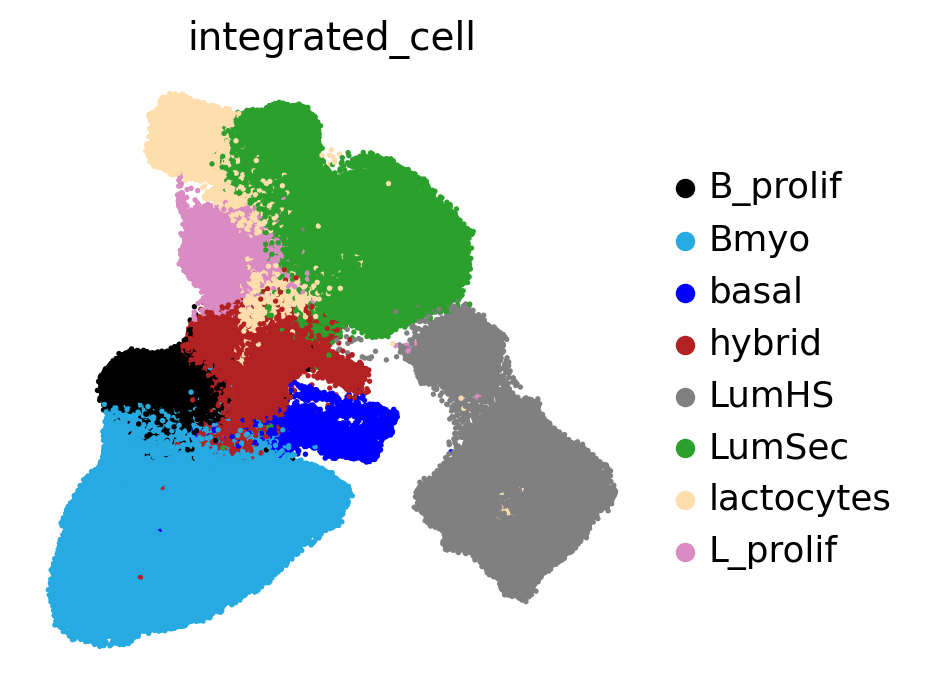

In [13]:
sc.pl.umap(
    full,
    color=["integrated_cell"],
    frameon=False,
    ncols=1,s=15,
    palette=['black', '#27AAE1','blue','firebrick','grey','#2ca02c','navajowhite','#da8bc3'
                         ]
)

In [15]:
us_CNV=pd.read_csv("/share/crsp/lab/dalawson/tzhuravl/CellPlex_Tumors/Scanpy_Seurat/merged_seurat/epithelial/copykat_subsampled/nor_subsampled_basal_lumsec_tumor_after_copykat.csv",index_col=0)
us_CNV.set_index("barcode", inplace=True)
full.obs['cnv_us'] = us_CNV['alt_copyKAT_pred_final']

In [16]:
wk_CNV=pd.read_csv("/share/crsp/lab/dalawson/share/Brca_mouse/WalidKhaled/ctrl2ctrl3_asnorm_from_all_copykat_prediction.txt",sep='\t')
wk_CNV.set_index("cell.names", inplace=True)
full.obs['cnv_wk'] = wk_CNV['copykat.pred']

In [17]:
res1 = pd.read_csv("/share/crsp/lab/dalawson/tzhuravl/CellPlex_Tumors/Scanpy_Seurat/scVI_epithelial/TNBC_subtyper/result_singlecell.csv")

#res1 = res1[res1['Unnamed: 0'].str.startswith('us')]
res1['Unnamed: 0'] = res1['Unnamed: 0'].str.replace('us_', '')
res1['Unnamed: 0'] = res1['Unnamed: 0'].str.replace('wk_', '')
res1['Unnamed: 0'] = res1['Unnamed: 0'].str.replace('vis_', '')
res1['Unnamed: 0'] = res1['Unnamed: 0'].str.replace('.', '-')

res1.set_index("Unnamed: 0", inplace=True)



res2 = pd.read_csv("/share/crsp/lab/dalawson/tzhuravl/CellPlex_Tumors/Scanpy_Seurat/scVI_epithelial/TNBC_subtyper/result_mouse_single_cell_lumhr_noESR.csv")

#res2 = res2[res2['Unnamed: 0'].str.startswith('us')]
res2['Unnamed: 0'] = res2['Unnamed: 0'].str.replace('us_', '')
res2['Unnamed: 0'] = res2['Unnamed: 0'].str.replace('wk_', '')
res2['Unnamed: 0'] = res2['Unnamed: 0'].str.replace('vis_', '')
res2['Unnamed: 0'] = res2['Unnamed: 0'].str.replace('.', '-')

res2.set_index("Unnamed: 0", inplace=True)



res3 = pd.read_csv("/share/crsp/lab/dalawson/tzhuravl/CellPlex_Tumors/Scanpy_Seurat/scVI_epithelial/TNBC_subtyper/result_mouse_single_cell_normal_epithelial_without_lumhr.csv")

#res3 = res3[res3['Unnamed: 0'].str.startswith('us')]
res3['Unnamed: 0'] = res3['Unnamed: 0'].str.replace('us_', '')
res3['Unnamed: 0'] = res3['Unnamed: 0'].str.replace('wk_', '')
res3['Unnamed: 0'] = res3['Unnamed: 0'].str.replace('vis_', '')
res3['Unnamed: 0'] = res3['Unnamed: 0'].str.replace('.', '-')

res3.set_index("Unnamed: 0", inplace=True)



res4 = pd.read_csv("/share/crsp/lab/dalawson/tzhuravl/CellPlex_Tumors/Scanpy_Seurat/scVI_epithelial/TNBC_subtyper/result_singlecell_basal_lumsec.csv")

res4['Unnamed: 0'] = res4['Unnamed: 0'].str.replace('.', '-')
res4.set_index("Unnamed: 0", inplace=True)



res = pd.concat([res1, res2, res3, res4], axis=0)

new_res = res[~res.index.duplicated(keep='first')]

full.obs['subtype'] = new_res['subtype']
full.obs['subtype_correlation'] = new_res['correlation']
full.obs['subtype_pval'] = new_res['p.value']

In [18]:
full.obs.rename(columns={"cnv_us": "cnv_wap_cre"}, inplace=True)
full.obs.rename(columns={"cnv_wk": "cnv_blg_cre"}, inplace=True)

In [19]:
full

AnnData object with n_obs × n_vars = 177306 × 838
    obs: 'orig.ident', 'pct_counts_mt', 'pct_counts_ribo', 'cell_type', 'barcode', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'leiden', 'dataset', '_scvi_batch', '_scvi_labels', 'scanvi_labels', 'batch', 'predictions_scanvi', 'integrated_cell', 'cnv_wap_cre', 'cnv_blg_cre', 'subtype', 'subtype_correlation', 'subtype_pval'
    uns: '_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'leiden', 'umap', 'predictions_scanvi_colors', 'leiden_colors', 'rank_genes_groups', 'dendrogram_leiden', 'integrated_cell_colors'
    obsm: 'X_pca', 'X_umap', 'X_scVI', 'X_scANVI'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

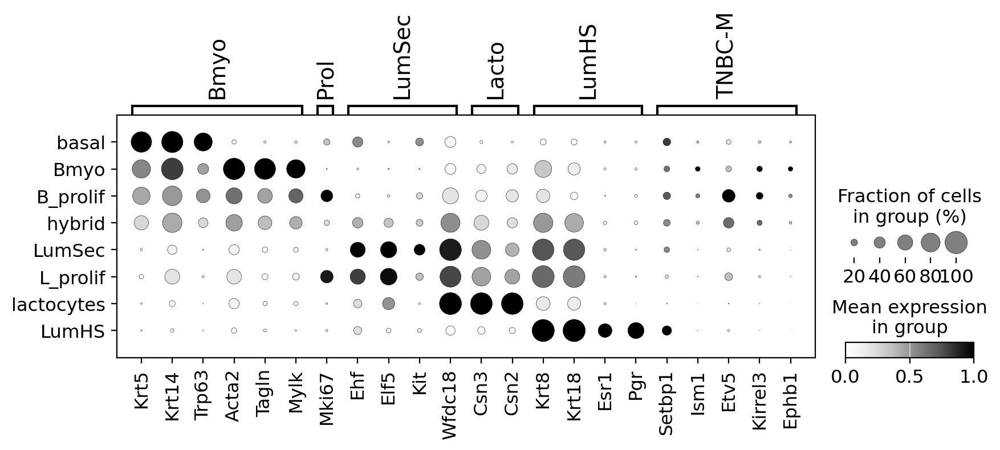

In [31]:
marker_genes = {
    "Bmyo": ["Krt5","Krt14","Trp63","Acta2","Tagln","Mylk"],
    "Prol": ["Mki67"],
    "LumSec": ["Ehf","Elf5","Kit","Wfdc18"],
    "Lacto": ["Csn3","Csn2"],
    "LumHS": ["Krt8","Krt18","Esr1","Pgr"],
    "TNBC-M":["Setbp1","Ism1","Etv5","Kirrel3","Ephb1"]}


sc.pl.dotplot(full, marker_genes, groupby="integrated_cell",
              standard_scale="var",
              categories_order=['basal','Bmyo','B_prolif',
              'hybrid','LumSec','L_prolif','lactocytes','LumHS'],
              swap_axes=False,cmap='Greys',save='_integrated_cell_canonical_M.pdf')

In [18]:
full.obs['batch'].value_counts()

batch
Reference    95483
Query        81823
Name: count, dtype: int64

In [17]:
full.obs['batch'] = full.obs["batch"].astype("str")
full.obs['cell_type'] = full.obs["cell_type"].astype("str")
full.obs['integrated_cell'] = full.obs["integrated_cell"].astype("str")

full.obs['ref_integrated_comparison_ref'] = full.obs['batch'] + ' ' + full.obs['cell_type']
full.obs['ref_integrated_comparison_integrated'] = full.obs['batch'] + ' ' + full.obs['integrated_cell']

In [18]:
full.obs['ref_integrated_comparison'] = np.where(full.obs['batch'] == 'Reference', full.obs['ref_integrated_comparison_ref'], full.obs['ref_integrated_comparison_integrated'])

In [19]:
full.obs['ref_integrated_comparison'] = (
    full.obs['ref_integrated_comparison']
    .astype("category")
)

In [20]:
full.obs['ref_integrated_comparison'].value_counts()

ref_integrated_comparison
Query Bmyo              33068
Reference Bmyo          32134
Reference LumSec        30267
Query LumHS             19793
Query LumSec            16942
Reference LumHS         15109
Query hybrid             4676
Reference lactocytes     4513
Reference L_prolif       4469
Reference hybrid         3452
Reference B_prolif       3223
Query B_prolif           2605
Query L_prolif           2377
Reference basal          2316
Query basal              2179
Query lactocytes          183
Name: count, dtype: int64

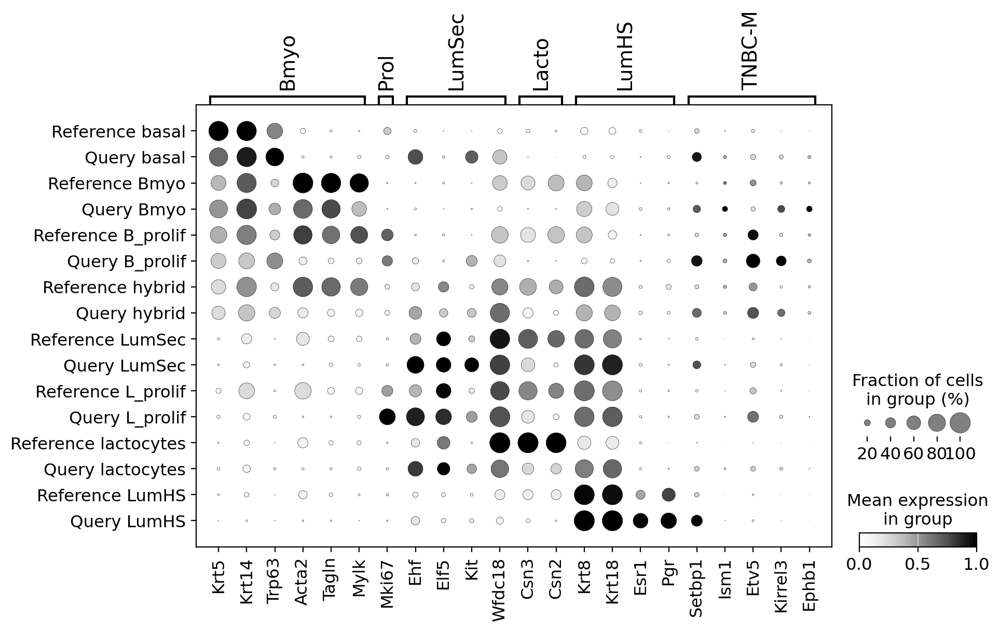

In [49]:
marker_genes = {
    "Bmyo": ["Krt5","Krt14","Trp63","Acta2","Tagln","Mylk"],
    "Prol": ["Mki67"],
    "LumSec": ["Ehf","Elf5","Kit","Wfdc18"],
    "Lacto": ["Csn3","Csn2"],
    "LumHS": ["Krt8","Krt18","Esr1","Pgr"],
    "TNBC-M":["Setbp1","Ism1","Etv5","Kirrel3","Ephb1"]}


sc.pl.dotplot(full, marker_genes, groupby="ref_integrated_comparison",
              standard_scale="var",
              categories_order=['Reference basal','Query basal',
                               'Reference Bmyo','Query Bmyo',
                               'Reference B_prolif','Query B_prolif',
                               'Reference hybrid','Query hybrid',
                               'Reference LumSec','Query LumSec',
                               'Reference L_prolif','Query L_prolif',
                               'Reference lactocytes','Query lactocytes',
                               'Reference LumHS','Query LumHS',],
              swap_axes=False,cmap='Greys',save='_integrated_cell_comparison_canonical_M.pdf')

In [21]:
full.obs['ref_integrated_comparison_integrated'] = (
    full.obs['ref_integrated_comparison_integrated']
    .astype("category")
)

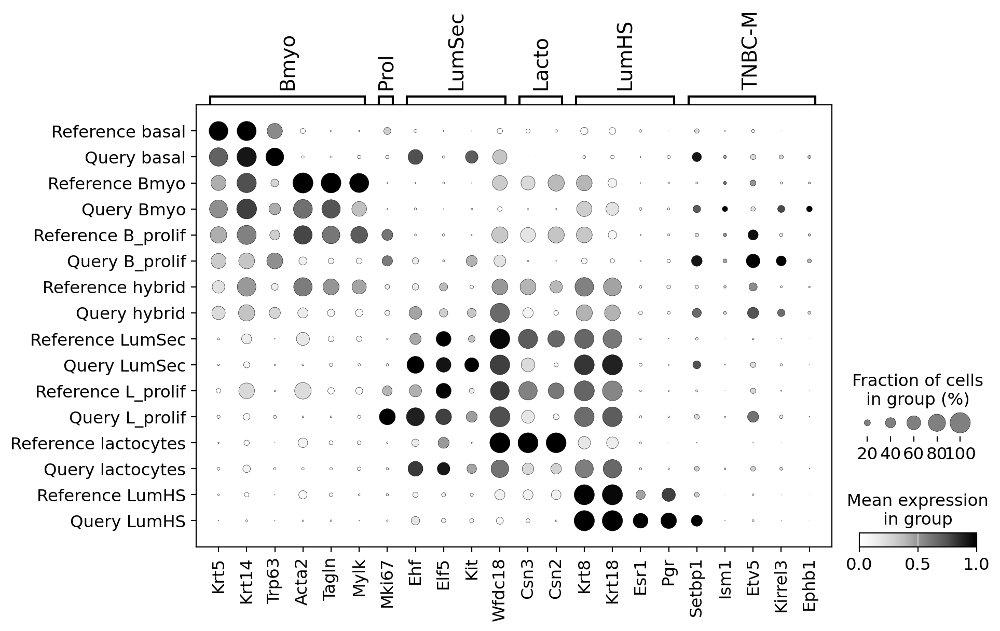

In [51]:
marker_genes = {
    "Bmyo": ["Krt5","Krt14","Trp63","Acta2","Tagln","Mylk"],
    "Prol": ["Mki67"],
    "LumSec": ["Ehf","Elf5","Kit","Wfdc18"],
    "Lacto": ["Csn3","Csn2"],
    "LumHS": ["Krt8","Krt18","Esr1","Pgr"],
    "TNBC-M":["Setbp1","Ism1","Etv5","Kirrel3","Ephb1"]}


sc.pl.dotplot(full, marker_genes, groupby="ref_integrated_comparison_integrated",
              standard_scale="var",
              categories_order=['Reference basal','Query basal',
                               'Reference Bmyo','Query Bmyo',
                               'Reference B_prolif','Query B_prolif',
                               'Reference hybrid','Query hybrid',
                               'Reference LumSec','Query LumSec',
                               'Reference L_prolif','Query L_prolif',
                               'Reference lactocytes','Query lactocytes',
                               'Reference LumHS','Query LumHS',],
              swap_axes=False,cmap='Greys',save='_integrated_cell_everywhere_comparison_canonical_M.pdf')

In [ ]:
#accidentally reset
marker_genes = {
    "Bmyo": ["Krt5","Krt14","Trp63","Acta2","Tagln","Mylk"],
    "Prol": ["Mki67"],
    "LumSec": ["Ehf","Elf5","Kit","Wfdc18"],
    "Lacto": ["Csn3","Csn2"],
    "LumHS": ["Krt8","Krt18","Esr1","Pgr"],
    "TNBC-M":["Setbp1","Ism1","Etv5","Kirrel3","Ephb1"]}


sc.pl.dotplot(full, marker_genes, groupby="ref_integrated_comparison_integrated",
              standard_scale="var",
              categories_order=['Reference basal','Query basal',
                               'Reference Bmyo','Query Bmyo',
                               'Reference B_prolif','Query B_prolif',
                               'Reference hybrid','Query hybrid',
                               'Reference LumSec','Query LumSec',
                               'Reference L_prolif','Query L_prolif',
                               'Reference lactocytes','Query lactocytes',
                               'Reference LumHS','Query LumHS',],
              swap_axes=False,cmap='Greys',save='_wap_blg_integrated_cell_everywhere_comparison_canonical_M.pdf')

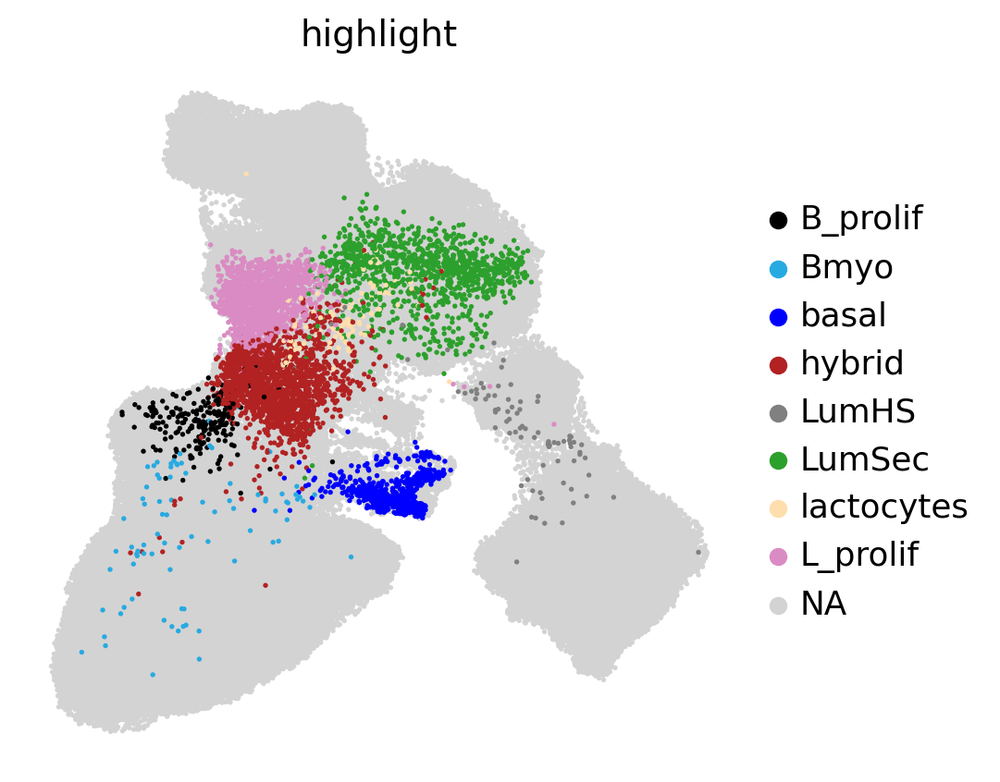

In [7]:
e18 = full[full.obs['orig.ident'].isin(["E18-ME"])]
full.obs['highlight'] = e18.obs['integrated_cell']

pl.rcParams["figure.figsize"] = (5,5)
sc.pl.umap(
    full,
    color=["highlight"],
    frameon=False,
    ncols=1,
    size=15,
    palette=['black', '#27AAE1','blue','firebrick','grey','#2ca02c','navajowhite','#da8bc3',
                         ],
)

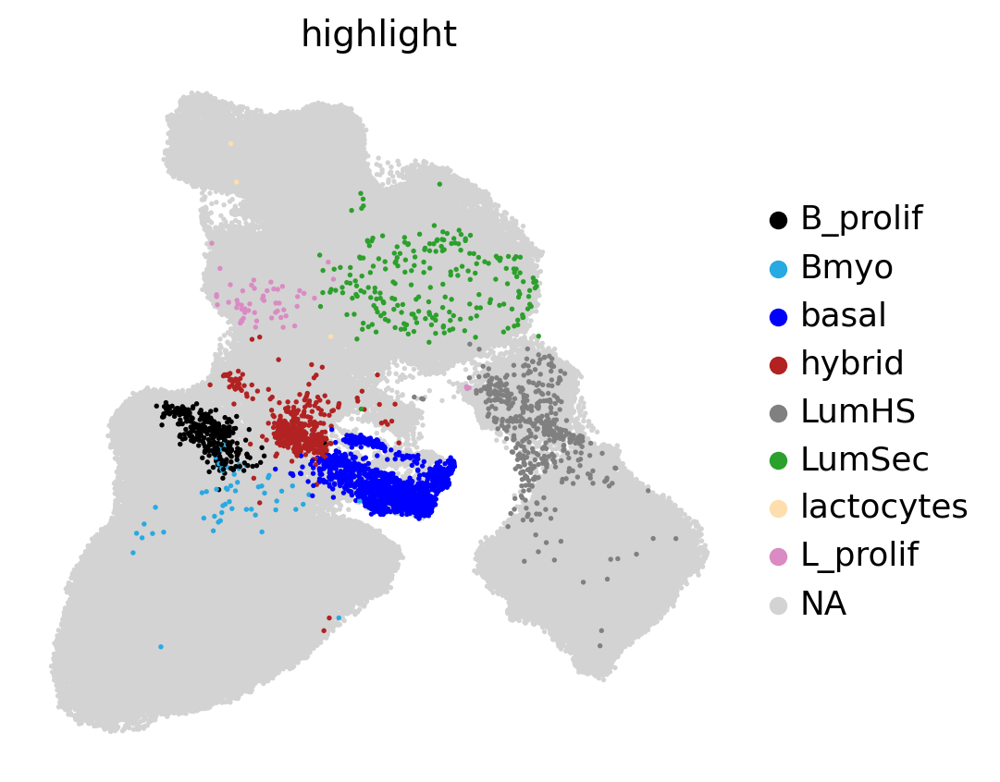

In [8]:
e18 = full[full.obs['orig.ident'].isin(["Pre-D5-BL6"])]
full.obs['highlight'] = e18.obs['integrated_cell']

pl.rcParams["figure.figsize"] = (5,5)
sc.pl.umap(
    full,
    color=["highlight"],
    frameon=False,
    ncols=1,
    size=15,
    palette=['black', '#27AAE1','blue','firebrick','grey','#2ca02c','navajowhite','#da8bc3',
                         ],
)

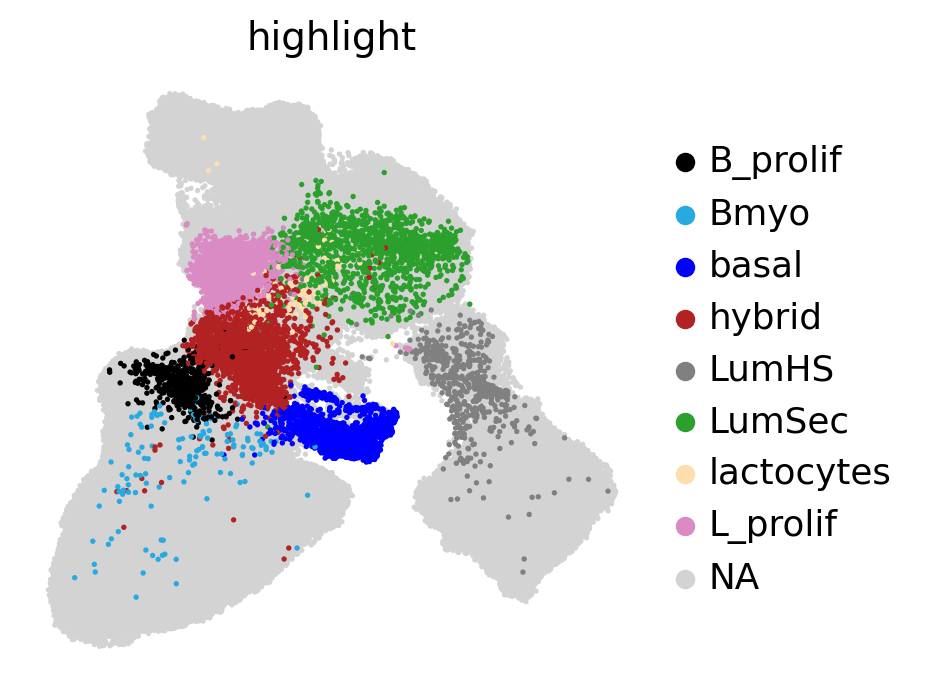

In [22]:
e18 = full[full.obs['orig.ident'].isin(["E18-ME","Pre-D5-BL6"])]
full.obs['highlight'] = e18.obs['integrated_cell']

#pl.rcParams["figure.figsize"] = (5,5)
sc.pl.umap(
    full,
    color=["highlight"],
    frameon=False,
    ncols=1,
    size=15,
    palette=['black', '#27AAE1','blue','firebrick','grey','#2ca02c','navajowhite','#da8bc3',
                         ],
)

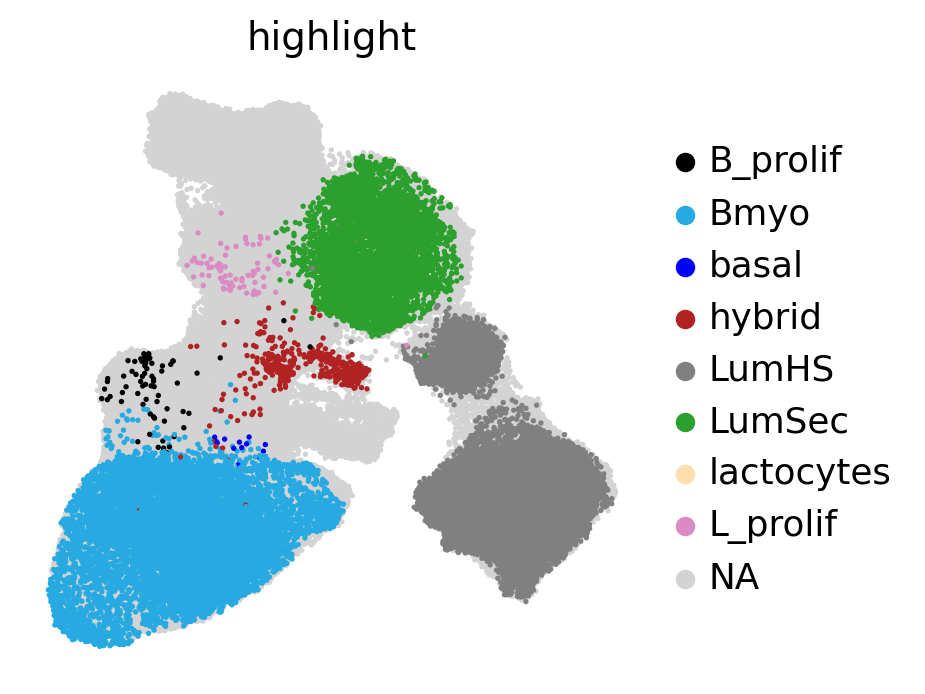

In [20]:
e18 = full[full.obs['orig.ident'].isin(["nMFP_2","nMFP_3","nMFP_4","nMFP_5","nMFP_6","nMFP_7","nMFP_8","nMFP_10",
                                        "nMFP_11","nMFP_12","nMFP_13","nMFP_14","nMFP_15",
                                        "CTRL_1","CTRL_2","CTRL_3","Adult-BL6"
                                       ])]
full.obs['highlight'] = e18.obs['integrated_cell']

#pl.rcParams["figure.figsize"] = (5,5)
sc.pl.umap(
    full,
    color=["highlight"],
    frameon=False,
    ncols=1,
    size=15,
    palette=['black', '#27AAE1','blue','firebrick','grey','#2ca02c','navajowhite','#da8bc3',
                         ],
)

In [22]:
us_CNV=pd.read_csv("/share/crsp/lab/dalawson/tzhuravl/CellPlex_Tumors/Scanpy_Seurat/merged_seurat/epithelial/copykat_subsampled/nor_subsampled_basal_lumsec_tumor_after_copykat.csv",index_col=0)
us_CNV.set_index("barcode", inplace=True)
full.obs['cnv_us'] = us_CNV['alt_copyKAT_pred_final']

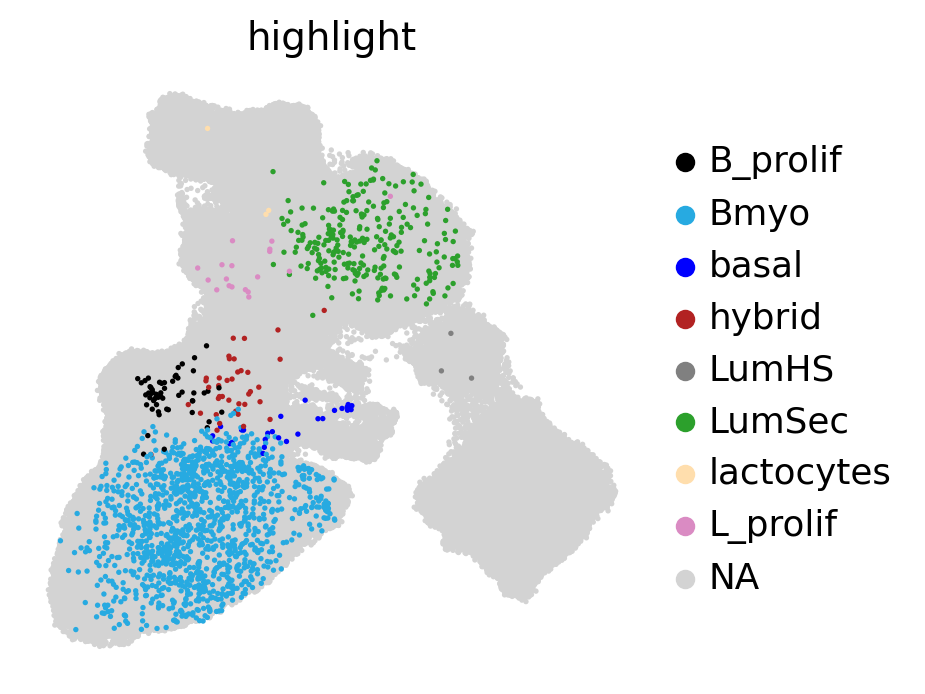

In [23]:
e18 = full[full.obs['orig.ident'].isin(["pMFP_1","pMFP_2","pMFP_3","pMFP_4","pMFP_5","pMFP_6","pMFP_7","pMFP_8","pMFP_9","pMFP_10",
                                           "pMFP_11","pMFP_12","pMFP_13","pMFP_14","pMFP_15",
                                       ])]
e18 = e18[e18.obs['cnv_us'].isin(["aneuploid"])]
full.obs['highlight'] = e18.obs['integrated_cell']

#pl.rcParams["figure.figsize"] = (5,5)
sc.pl.umap(
    full,
    color=["highlight"],
    frameon=False,
    ncols=1,
    size=15,
    palette=['black', '#27AAE1','blue','firebrick','grey','#2ca02c','navajowhite','#da8bc3',
                         ],
)

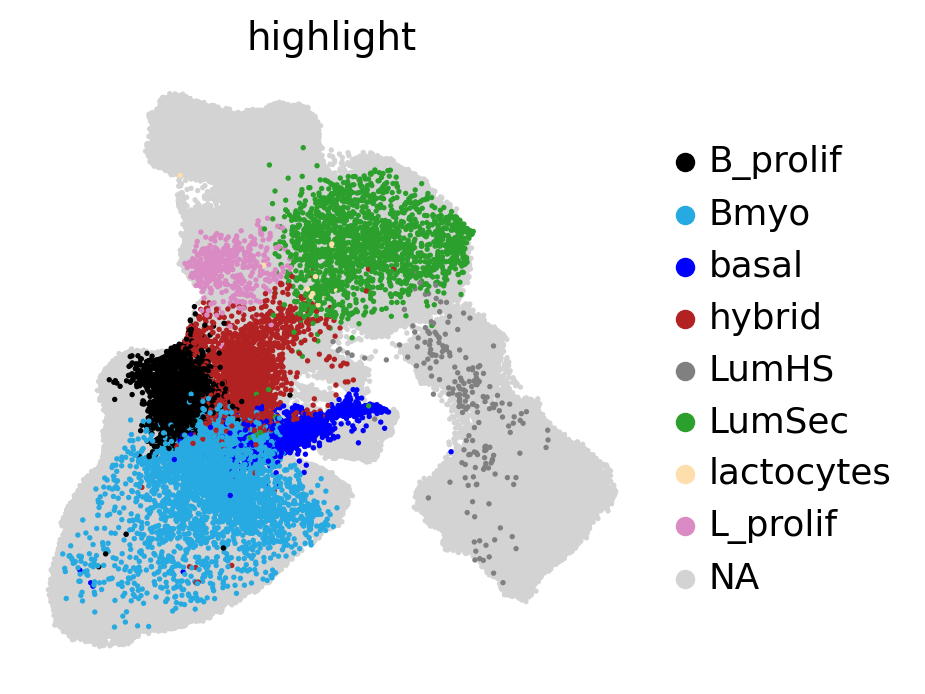

In [25]:
e18 = full[full.obs['orig.ident'].isin(["tum_599","tum_633","tum_081720",
                                            "tum_111121","tum_111121_enr","tum_966","tum_or_pMFP_654",
                                            "tum_120519"])]
e18 = e18[e18.obs['cnv_us'].isin(["aneuploid"])]
full.obs['highlight'] = e18.obs['integrated_cell']

#pl.rcParams["figure.figsize"] = (5,5)
sc.pl.umap(
    full,
    color=["highlight"],
    frameon=False,
    ncols=1,
    size=15,
    palette=['black', '#27AAE1','blue','firebrick','grey','#2ca02c','navajowhite','#da8bc3',
                         ],
)

In [23]:
wk_CNV=pd.read_csv("/share/crsp/lab/dalawson/share/Brca_mouse/WalidKhaled/ctrl2ctrl3_asnorm_from_all_copykat_prediction.txt",sep='\t')
wk_CNV.set_index("cell.names", inplace=True)
full.obs['cnv_wk'] = wk_CNV['copykat.pred']

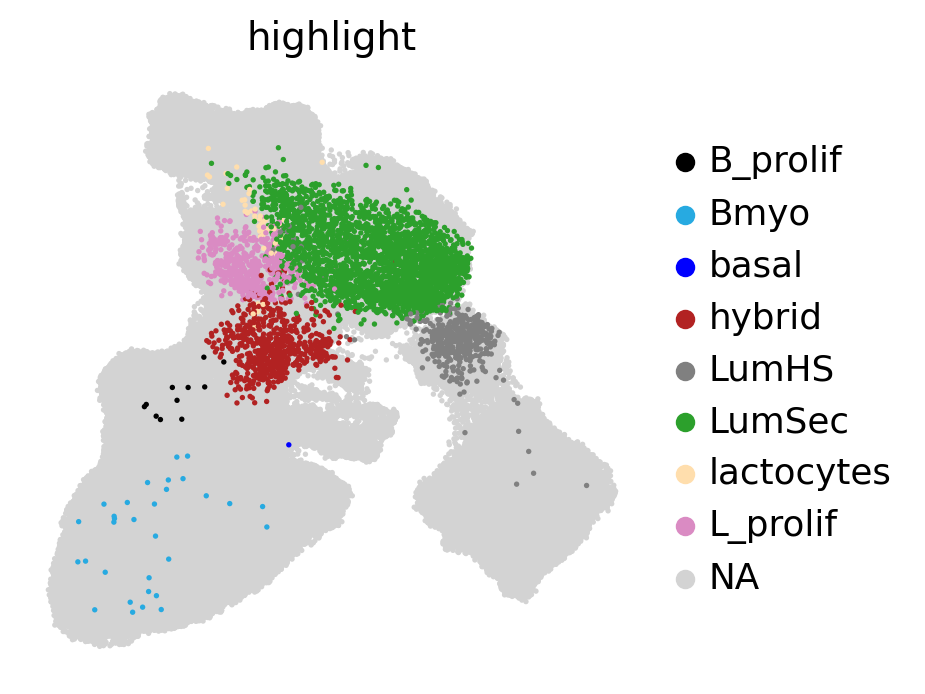

In [36]:
e18 = full[full.obs['orig.ident'].isin(["WKBR65.2f","WKBR65.2g","WKBR91.1f",
                                            "WKBR90.3i","WKBR91.1e","WKBR65.3h","WKBR90.3g",
                                           "WKBR65.3g","WKBR76.4f","WKBR65.3i","WKBR91.3j",
                                       "WKBR61.4dMG","WKBR75.4bMG"])]
e18 = e18[e18.obs['cnv_wk'].isin(["aneuploid"])]
full.obs['highlight'] = e18.obs['integrated_cell']

#pl.rcParams["figure.figsize"] = (5,5)
sc.pl.umap(
    full,
    color=["highlight"],
    frameon=False,
    ncols=1,
    size=15,
    palette=['black','#27AAE1','blue','firebrick','grey','#2ca02c','navajowhite','#da8bc3',
                         ],
)

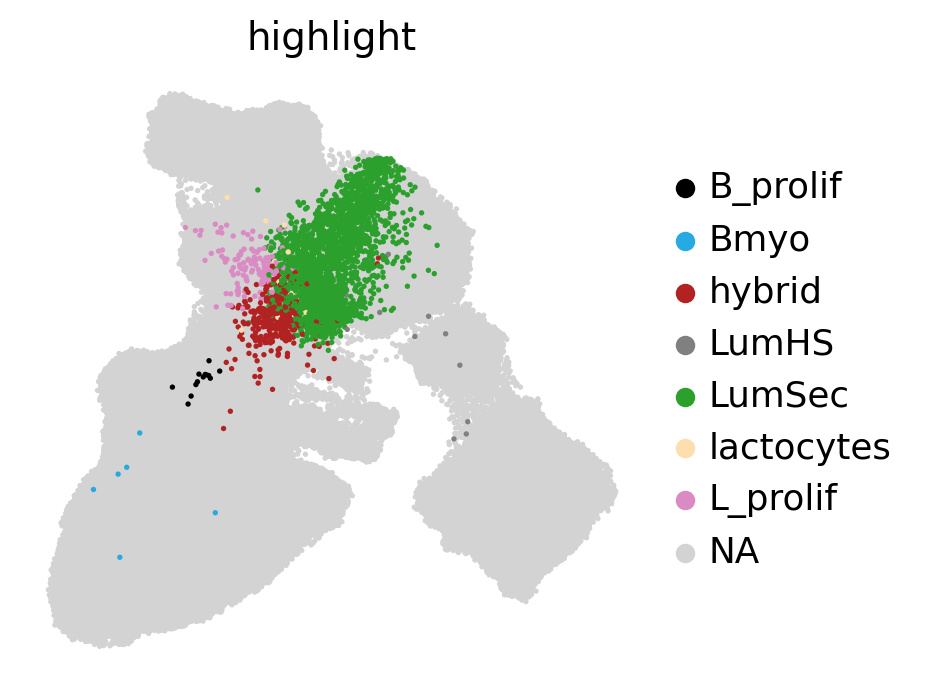

In [33]:
e18 = full[full.obs['orig.ident'].isin(["WKBR61.4dTM","WKBR75.4bTM"])]
e18 = e18[e18.obs['cnv_wk'].isin(["aneuploid"])]
full.obs['highlight'] = e18.obs['integrated_cell']

#pl.rcParams["figure.figsize"] = (5,5)
sc.pl.umap(
    full,
    color=["highlight"],
    frameon=False,
    ncols=1,
    size=15,
    palette=['black','#27AAE1','firebrick','grey','#2ca02c','navajowhite','#da8bc3',
                         ],
)

In [24]:
full.obs['dataset'] = full.obs["dataset"].astype("str")
full.obs['integrated_cell'] = full.obs["integrated_cell"].astype("str")

full.obs['wap_blg_integrated_comparison_integrated'] = full.obs['dataset'] + ' ' + full.obs['integrated_cell']
full.obs['wap_blg_integrated_comparison_integrated'] = (
    full.obs['wap_blg_integrated_comparison_integrated']
    .astype("category")
)

In [76]:
sub = full[full.obs['orig.ident'].isin(["E18-ME","Pre-D5-BL6",'E18-Skin','Pre-BL6','Duct','TEB',"Adult-BL6",'Preg-D12','Preg-D12-G','Preg-D18','Preg-D18-B4',
                                                                                                     'Lac-D10','Lac-D10-D6',
                                                                                                 'PI-W3',
    "WKBR61.4dTM","WKBR75.4bTM",
                                       "tum_599","tum_633","tum_081720",
                                            "tum_111121","tum_111121_enr","tum_966","tum_or_pMFP_654",
                                            "tum_120519"])]
sub = sub[~sub.obs['cnv_wk'].isin(["diploid","not.defined"])]
sub = sub[~sub.obs['cnv_us'].isin(["diploid","not.defined"])]

In [77]:
sub.obs['wap_blg_integrated_comparison_integrated'].value_counts()

wap_blg_integrated_comparison_integrated
development Bmyo          25890
development LumSec        22846
development LumHS         12102
development lactocytes     6557
development L_prolif       6367
development hybrid         5456
development B_prolif       3610
wap_cre Bmyo               3114
development basal          2461
blg_cre LumSec             2423
wap_cre hybrid             2280
wap_cre B_prolif           2126
wap_cre basal              2018
wap_cre LumSec             1816
wap_cre L_prolif            437
blg_cre hybrid              396
wap_cre LumHS               357
blg_cre L_prolif            142
blg_cre LumHS                31
blg_cre lactocytes           26
blg_cre B_prolif             13
wap_cre lactocytes           13
blg_cre Bmyo                  6
Name: count, dtype: int64

/opt/apps/python/3.10.2/lib/python3.10/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/opt/apps/python/3.10.2/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/apps/python/3.10.2/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/apps/python/3.10.2/lib/python3.10/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/opt/apps/python/3.10.2/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs

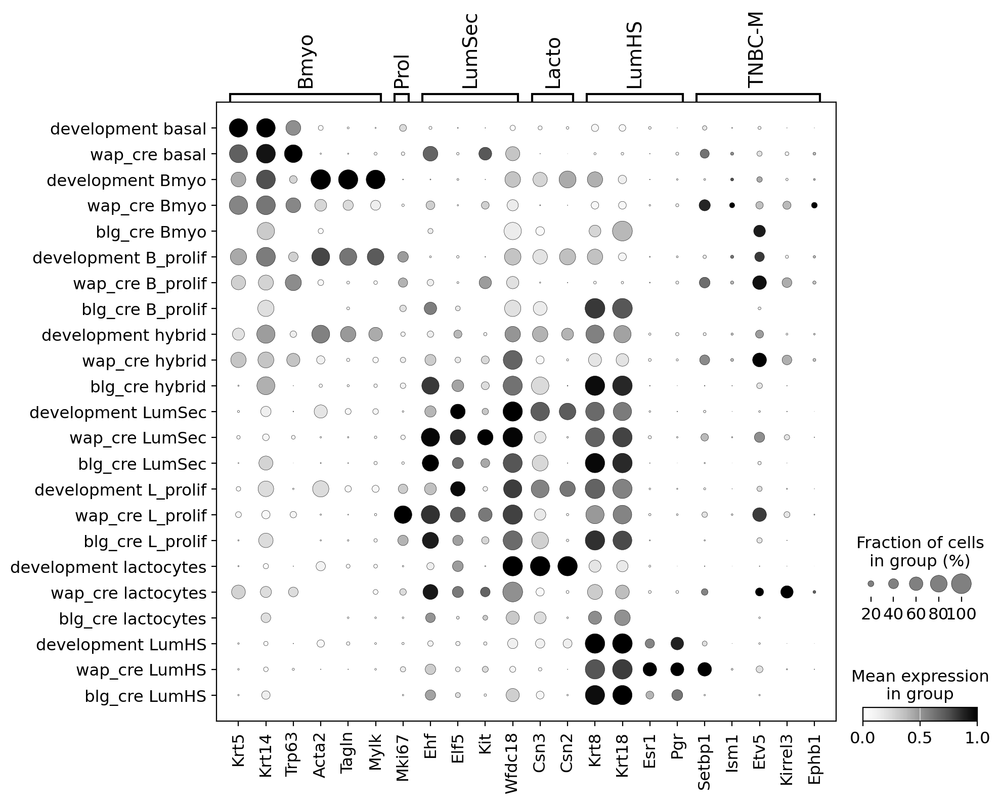

In [78]:
marker_genes = {
    "Bmyo": ["Krt5","Krt14","Trp63","Acta2","Tagln","Mylk"],
    "Prol": ["Mki67"],
    "LumSec": ["Ehf","Elf5","Kit","Wfdc18"],
    "Lacto": ["Csn3","Csn2"],
    "LumHS": ["Krt8","Krt18","Esr1","Pgr"],
    "TNBC-M":["Setbp1","Ism1","Etv5","Kirrel3","Ephb1"]}


sc.pl.dotplot(sub, marker_genes, groupby="wap_blg_integrated_comparison_integrated",
              standard_scale="var",
              categories_order=['development basal','wap_cre basal',
                               'development Bmyo','wap_cre Bmyo','blg_cre Bmyo',
                              'development B_prolif', 'wap_cre B_prolif','blg_cre B_prolif',
                               'development hybrid','wap_cre hybrid','blg_cre hybrid',
                               'development LumSec','wap_cre LumSec','blg_cre LumSec',
                               'development L_prolif','wap_cre L_prolif','blg_cre L_prolif',
                               'development lactocytes','wap_cre lactocytes','blg_cre lactocytes',
                               'development LumHS','wap_cre LumHS','blg_cre LumHS',],
              swap_axes=False,cmap='Greys',save='_wap_blg_integrated_cell_everywhere_comparison_canonical_M.pdf')

In [26]:
df1 = full[full.obs['orig.ident'].isin(["E18-ME","Pre-D5-BL6"])]


df2 = full[full.obs['orig.ident'].isin(["nMFP_2","nMFP_3","nMFP_4","nMFP_5","nMFP_6","nMFP_7","nMFP_8","nMFP_10",
                                        "nMFP_11","nMFP_12","nMFP_13","nMFP_14","nMFP_15",
                                        "CTRL_1","CTRL_2","CTRL_3","Adult-BL6"
                                       ])]


df3 = full[full.obs['orig.ident'].isin(["pMFP_1","pMFP_2","pMFP_3","pMFP_4","pMFP_5","pMFP_6","pMFP_7","pMFP_8","pMFP_9","pMFP_10",
                                           "pMFP_11","pMFP_12","pMFP_13","pMFP_14","pMFP_15",
                                       ])]
df3 = df3[df3.obs['cnv_us'].isin(["aneuploid"])]


df4 = full[full.obs['orig.ident'].isin(["tum_599","tum_633","tum_081720",
                                            "tum_111121","tum_111121_enr","tum_966","tum_or_pMFP_654",
                                            "tum_120519"])]
df4 = df4[df4.obs['cnv_us'].isin(["aneuploid"])]


df5 = full[full.obs['orig.ident'].isin(["WKBR65.2f","WKBR65.2g","WKBR91.1f",
                                            "WKBR90.3i","WKBR91.1e","WKBR65.3h","WKBR90.3g",
                                           "WKBR65.3g","WKBR76.4f","WKBR65.3i","WKBR91.3j",
                                       "WKBR61.4dMG","WKBR75.4bMG"])]
df5 = df5[df5.obs['cnv_wk'].isin(["aneuploid"])]


df6 = full[full.obs['orig.ident'].isin(["WKBR61.4dTM","WKBR75.4bTM"])]
df6 = df6[df6.obs['cnv_wk'].isin(["aneuploid"])]


df7 = full[full.obs['orig.ident'].isin(['E18-Skin','Pre-BL6','Duct','TEB','Preg-D12','Preg-D12-G','Preg-D18','Preg-D18-B4',
                                                                                                     'Lac-D10','Lac-D10-D6',
                                                                                                 'PI-W3'])]

In [27]:
all_cells=df1.obs_names.to_list()+df2.obs_names.to_list()+df3.obs_names.to_list()+df4.obs_names.to_list()+df5.obs_names.to_list()+df6.obs_names.to_list()+df7.obs_names.to_list()

In [28]:
len(all_cells)

124145

In [29]:
e18 = full[full.obs_names.isin(all_cells)]
#e18 = e18[~e18.obs['orig.ident'].isin(["Preg-D12-G"])]

e18

View of AnnData object with n_obs × n_vars = 124146 × 838
    obs: 'orig.ident', 'pct_counts_mt', 'pct_counts_ribo', 'cell_type', 'barcode', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'leiden', 'dataset', 'dev_stage', '_scvi_batch', '_scvi_labels', 'scanvi_labels', 'batch', 'predictions_scanvi', 'cell_type_blg', 'cell_type_wap', 'cell_type_mets', 'cell_type_vis', 'integrated_cell', 'ref_integrated_comparison_ref', 'ref_integrated_comparison_integrated', 'ref_integrated_comparison', 'cnv_us', 'cnv_wk', 'wap_blg_integrated_comparison_integrated'
    uns: '_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'leiden', 'umap', 'dataset_colors', 'cell_type_blg_colors', 'cell_type_wap_colors', 'cell_type_mets_colors', 'cell_type_vis_colors', '

In [9]:
full = full[full.obs_names.isin(all_cells)]

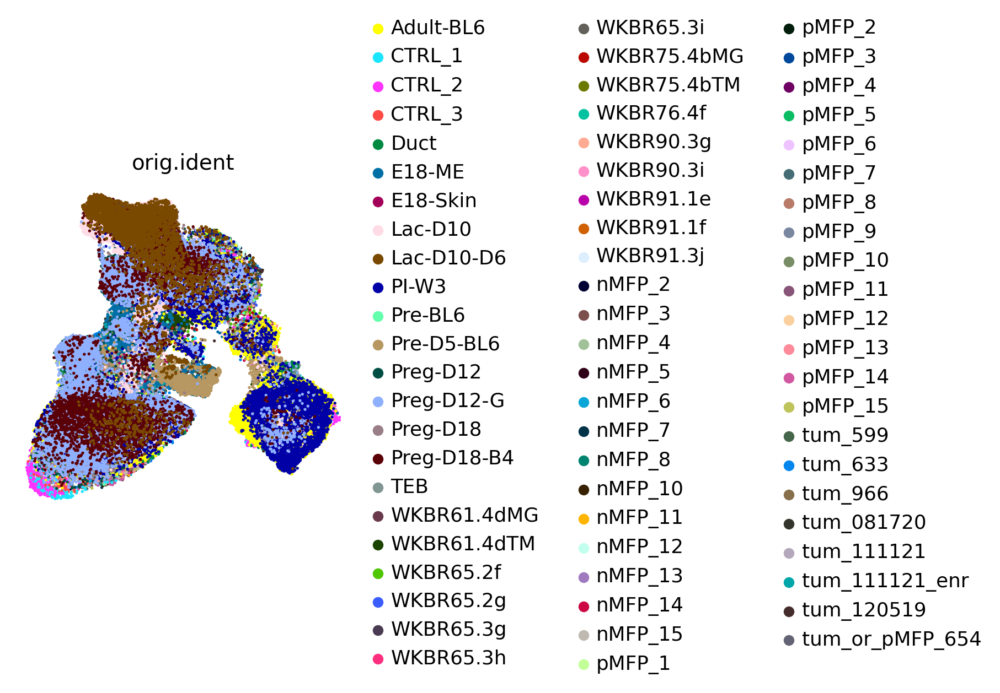

In [11]:
sc.pl.umap(
    full,
    color=["orig.ident"],
    frameon=False,
    ncols=1,s=15,save='_full_origident.pdf'
    #palette=['black', '#27AAE1','blue','darkorange','navajowhite','#da8bc3',
                         #'grey','#2ca02c']
)

In [60]:
e18.obs['Fig_5_ident'] = (
    e18.obs["orig.ident"]
    .map(lambda x: {"E18-ME": "Embryonic Day 18",
                    "Pre-D5-BL6": "Postnatal Day 5",
                    "nMFP_2": "Adult Week 19",
                    "nMFP_3": "Adult Week 19",
                    "nMFP_4": "Adult Week 19",
                    "nMFP_5": "Adult Week 19",
                    "nMFP_6": "Adult Week 19",
                    "nMFP_7": "Adult Week 19",
                    "nMFP_8": "Adult Week 19",
                    "nMFP_10": "Adult Week 19",
                    "nMFP_11": "Adult Week 19",
                    "nMFP_12": "Adult Week 19",
                    "nMFP_13": "Adult Week 19",
                    "nMFP_14": "Adult Week 19",
                    "nMFP_15": "Adult Week 19",
                    "CTRL_1": "Adult Week 12",
                    "CTRL_2": "Adult Week 12",
                    "CTRL_3": "Adult Week 12",
                    "Adult-BL6": "Adult Week 10",
                    "pMFP_1": "WAP-Cre aneuploid",
                    "pMFP_2": "WAP-Cre aneuploid",
                    "pMFP_3": "WAP-Cre aneuploid",
                    "pMFP_4": "WAP-Cre aneuploid",
                    "pMFP_5": "WAP-Cre aneuploid",
                    "pMFP_6": "WAP-Cre aneuploid",
                    "pMFP_7": "WAP-Cre aneuploid",
                    "pMFP_8": "WAP-Cre aneuploid",
                    "pMFP_9": "WAP-Cre aneuploid",
                    "pMFP_10": "WAP-Cre aneuploid",
                    "pMFP_11": "WAP-Cre aneuploid",
                    "pMFP_12": "WAP-Cre aneuploid",
                    "pMFP_13": "WAP-Cre aneuploid",
                    "pMFP_14": "WAP-Cre aneuploid",
                    "pMFP_15": "WAP-Cre aneuploid",
                    "tum_599": "WAP-Cre aneuploid tumor",
                    "tum_633": "WAP-Cre aneuploid tumor",
                    "tum_081720": "WAP-Cre aneuploid tumor",
                    "tum_111121": "WAP-Cre aneuploid tumor",
                    "tum_111121_enr": "WAP-Cre aneuploid tumor",
                    "tum_966": "WAP-Cre aneuploid tumor",
                    "tum_654": "WAP-Cre aneuploid tumor",
                    "tum_120519": "WAP-Cre aneuploid tumor",
                    "WKBR65.2f": "Blg-Cre aneuploid",
                    "WKBR65.2g": "Blg-Cre aneuploid",
                    "WKBR91.1f": "Blg-Cre aneuploid",
                    "WKBR90.3i": "Blg-Cre aneuploid",
                    "WKBR91.1e": "Blg-Cre aneuploid",
                    "WKBR65.3h": "Blg-Cre aneuploid",
                    "WKBR90.3g": "Blg-Cre aneuploid",
                    "WKBR65.3g": "Blg-Cre aneuploid",
                    "WKBR76.4f": "Blg-Cre aneuploid",
                    "WKBR65.3i": "Blg-Cre aneuploid",
                    "WKBR91.3j": "Blg-Cre aneuploid",
                    "WKBR61.4dMG": "Blg-Cre aneuploid",
                    "WKBR75.4bMG": "Blg-Cre aneuploid",
                    "WKBR61.4dTM": "Blg-Cre aneuploid tumor",
                    "WKBR75.4bTM": "Blg-Cre aneuploid tumor",
                   "E18-Skin": "Embryonic Day 18 skin",
                    "Pre-BL6": "Prepuberty Week 2",
                    "Duct": "Puberty Week 5 Duct",
                    "TEB": "Puberty Week 5 TEB",
                    "Preg-D12": "Pregnancy Day 12",
                    "Preg-D12-G": "Pregnancy Day 12",
                    "Preg-D18": "Pregnancy Day 18",
                    "Preg-D18-B4": "Pregnancy Day 18",
                    "Lac-D10": "Lactation Day 10",
                    "Lac-D10-D6": "Lactation Day 10",
                    "PI-W3": "Post-involution Day 21"}.get(x, x))
    .astype("category")
)

/tmp/ipykernel_2609127/2087651381.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  e18.obs['Fig_5_ident'] = (
/opt/apps/python/3.10.2/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/apps/python/3.10.2/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [61]:
e18.obs['Fig_5_ident'].value_counts()

Fig_5_ident
Pregnancy Day 12           23999
Pregnancy Day 18           15949
Lactation Day 10           12055
WAP-Cre aneuploid tumor    12008
Adult Week 19              11469
Adult Week 10              10776
Post-involution Day 21      8748
Adult Week 12               6795
Embryonic Day 18            5587
Blg-Cre aneuploid           4379
Postnatal Day 5             3093
Blg-Cre aneuploid tumor     3018
WAP-Cre aneuploid           1704
Puberty Week 5 TEB          1664
Puberty Week 5 Duct         1631
Prepuberty Week 2           1630
Embryonic Day 18 skin        158
Name: count, dtype: int64

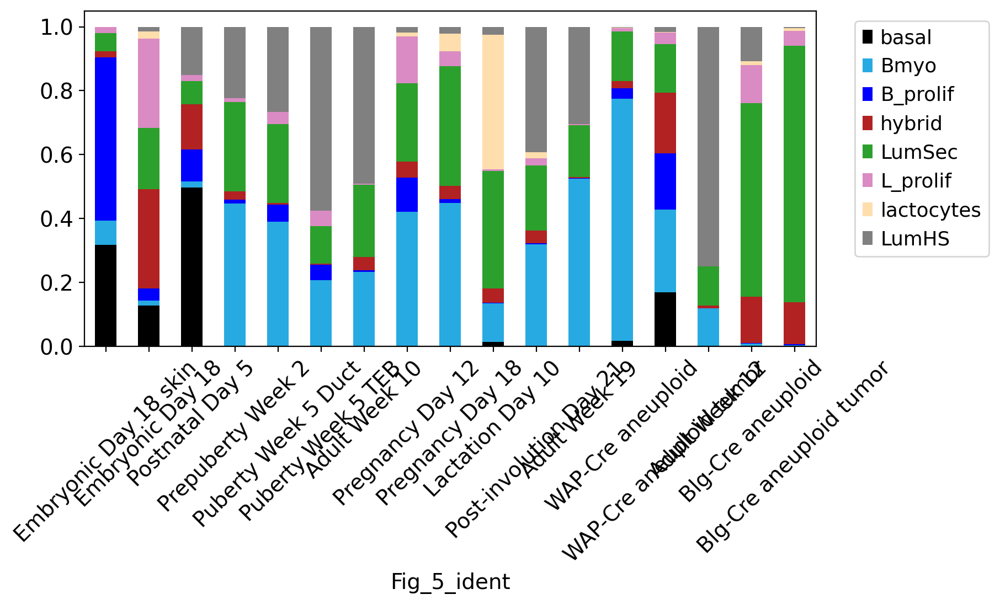

In [67]:
pl.rcParams["figure.figsize"] = (8.5,4)
tmp = pd.crosstab(e18.obs['integrated_cell'],e18.obs['Fig_5_ident'], 
                  normalize='columns').reindex(['basal','Bmyo','B_prolif',
              'hybrid','LumSec','L_prolif','lactocytes','LumHS'])[['Embryonic Day 18 skin',
                                                 'Embryonic Day 18',
                                                 'Postnatal Day 5',
                                                 'Prepuberty Week 2',
                                                 'Puberty Week 5 Duct',
                                                 'Puberty Week 5 TEB',
                                                 'Adult Week 10',
                                                 'Pregnancy Day 12',
                                                 'Pregnancy Day 18',
                                                 'Lactation Day 10',
                                                 'Post-involution Day 21',
                                                  'Adult Week 19',
                                                  'WAP-Cre aneuploid',
                                                 'WAP-Cre aneuploid tumor',
                                                  'Adult Week 12',
                                                  'Blg-Cre aneuploid',
                                                  'Blg-Cre aneuploid tumor']].T.plot(kind='bar', 
                                                                                            stacked=True,
                                                                                            color=['black', 
                                                                                                                        '#27AAE1',
                                                                                                                        'blue',
                                                                                                                        'firebrick',
                                                                                                                        '#2ca02c',
                                                                                                                       '#da8bc3',
                                                                                                   'navajowhite',
                                                                                                  'grey'])
tmp.legend(title='', bbox_to_anchor=(1.25, 1.0),loc='upper right')
pl.grid(None)
pl.xticks(rotation=45)
pl.savefig('Fig_5_ident_integrated_cell_stackedbar_plot.pdf', bbox_inches='tight')

In [36]:
wap = e18[e18.obs['dataset'].isin(['wap_cre','blg_cre'])]

In [37]:
wap.obs['Fig_5_ident'] = (
    wap.obs["orig.ident"]
    .map(lambda x: {
                    "pMFP_1": "WAP-Cre aneuploid 1",
                    "pMFP_2": "WAP-Cre aneuploid 2",
                    "pMFP_3": "WAP-Cre aneuploid 3",
                    "pMFP_4": "WAP-Cre aneuploid 4",
                    "pMFP_5": "WAP-Cre aneuploid 5",
                    "pMFP_6": "WAP-Cre aneuploid 6",
                    "pMFP_7": "WAP-Cre aneuploid 7",
                    "pMFP_8": "WAP-Cre aneuploid 8",
                    "pMFP_9": "WAP-Cre aneuploid 9",
                    "pMFP_10": "WAP-Cre aneuploid 10",
                    "pMFP_11": "WAP-Cre aneuploid 11",
                    "pMFP_12": "WAP-Cre aneuploid 12",
                    "pMFP_13": "WAP-Cre aneuploid 13",
                    "pMFP_14": "WAP-Cre aneuploid 14",
                    "pMFP_15": "WAP-Cre aneuploid 15",
                    "tum_599": "WAP-Cre aneuploid tumor 4",
                    "tum_633": "WAP-Cre aneuploid tumor 3",
                    "tum_081720": "WAP-Cre aneuploid tumor 6",
                    "tum_111121": "WAP-Cre aneuploid tumor 5",
                    "tum_111121_enr": "WAP-Cre aneuploid tumor 5",
                    "tum_966": "WAP-Cre aneuploid tumor 2",
                    "tum_or_pMFP_654": "WAP-Cre aneuploid tumor 1",
                    "tum_120519": "WAP-Cre aneuploid tumor 7",
                    "WKBR65.2f": "Blg-Cre aneuploid 1",
                    "WKBR65.2g": "Blg-Cre aneuploid 2",
                    "WKBR91.1f": "Blg-Cre aneuploid 9",
                    "WKBR90.3i": "Blg-Cre aneuploid 8",
                    "WKBR91.1e": "Blg-Cre aneuploid 10",
                    "WKBR65.3h": "Blg-Cre aneuploid 4",
                    "WKBR90.3g": "Blg-Cre aneuploid 7",
                    "WKBR65.3g": "Blg-Cre aneuploid 3",
                    "WKBR76.4f": "Blg-Cre aneuploid 6",
                    "WKBR65.3i": "Blg-Cre aneuploid 5",
                    "WKBR91.3j": "Blg-Cre aneuploid 11",
                    "WKBR61.4dMG": "Blg-Cre aneuploid 12",
                    "WKBR75.4bMG": "Blg-Cre aneuploid 13",
                    "WKBR61.4dTM": "Blg-Cre aneuploid tumor 1",
                    "WKBR75.4bTM": "Blg-Cre aneuploid tumor 2",
                   }.get(x, x))
    .astype("category")
)

/tmp/ipykernel_1206108/1685196980.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  wap.obs['Fig_5_ident'] = (


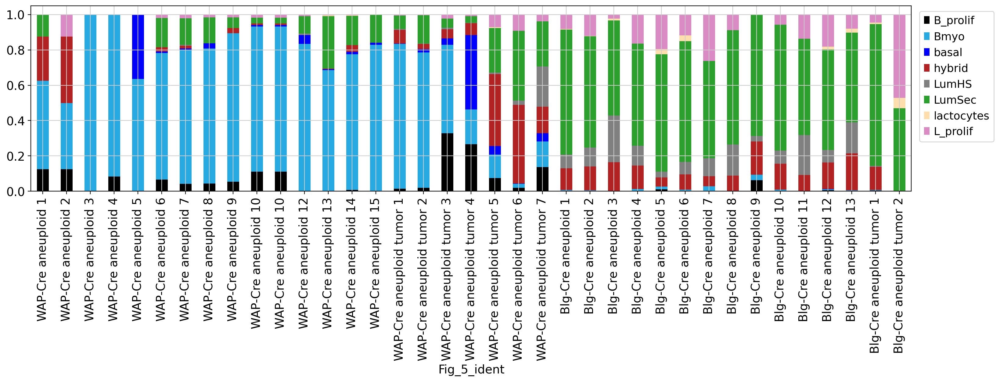

In [45]:
pl.rcParams["figure.figsize"] = (18.5,4)
tmp = pd.crosstab(wap.obs['integrated_cell'],wap.obs['Fig_5_ident'], 
                  normalize='columns').reindex()[["WAP-Cre aneuploid 1",
                                                  "WAP-Cre aneuploid 2",
                                                  "WAP-Cre aneuploid 3",
                                                  "WAP-Cre aneuploid 4",
                                                  "WAP-Cre aneuploid 5",
                                                  "WAP-Cre aneuploid 6",
                                                  "WAP-Cre aneuploid 7",
                                                  "WAP-Cre aneuploid 8",
                                                  "WAP-Cre aneuploid 9",
                                                  "WAP-Cre aneuploid 10",
                                                  "WAP-Cre aneuploid 10",
                                                  "WAP-Cre aneuploid 12",
                                                  "WAP-Cre aneuploid 13",
                                                  "WAP-Cre aneuploid 14",
                                                  "WAP-Cre aneuploid 15",
                                                 'WAP-Cre aneuploid tumor 1',
                                                  'WAP-Cre aneuploid tumor 2',
                                                  'WAP-Cre aneuploid tumor 3',
                                                  'WAP-Cre aneuploid tumor 4',
                                                  'WAP-Cre aneuploid tumor 5',
                                                  'WAP-Cre aneuploid tumor 6',
                                                  'WAP-Cre aneuploid tumor 7',
                                                 'Blg-Cre aneuploid 1',
                                                  'Blg-Cre aneuploid 2',
                                                  'Blg-Cre aneuploid 3',
                                                  'Blg-Cre aneuploid 4',
                                                  'Blg-Cre aneuploid 5',
                                                  'Blg-Cre aneuploid 6',
                                                  'Blg-Cre aneuploid 7',
                                                  'Blg-Cre aneuploid 8',
                                                  'Blg-Cre aneuploid 9',
                                                  'Blg-Cre aneuploid 10',
                                                  'Blg-Cre aneuploid 11',
                                                  'Blg-Cre aneuploid 12',
                                                  'Blg-Cre aneuploid 13',
                                                 'Blg-Cre aneuploid tumor 1',
                                                 'Blg-Cre aneuploid tumor 2']].T.plot(kind='bar', 
                                                                                            stacked=True,
                                                                                            color=['black', 
                                                                                                                        '#27AAE1',
                                                                                                                        'blue',
                                                                                                                        'firebrick',
                                                                                                                        'grey',
                                                                                                                        '#2ca02c',
                                                                                                                        'navajowhite',
                                                                                                                       '#da8bc3'])
tmp.legend(title='', bbox_to_anchor=(1.1, 1.0),loc='upper right')

pl.savefig('Fig_5_aneu_ident_integrated_cell_stackedbar_plot.pdf', bbox_inches='tight')

In [39]:
wap.obs['Fig_5_ident'].value_counts()

Fig_5_ident
WAP-Cre aneuploid tumor 4    4241
CTRL_2                       3802
Blg-Cre aneuploid tumor 1    3001
WAP-Cre aneuploid tumor 5    2354
CTRL_1                       2268
WAP-Cre aneuploid tumor 3    2134
WAP-Cre aneuploid tumor 6    1777
nMFP_5                       1131
nMFP_4                       1126
Blg-Cre aneuploid 13         1066
nMFP_14                       964
nMFP_15                       958
nMFP_11                       953
Blg-Cre aneuploid 1           942
Blg-Cre aneuploid 12          905
nMFP_12                       903
nMFP_2                        868
nMFP_10                       866
nMFP_6                        850
nMFP_3                        837
nMFP_13                       746
CTRL_3                        725
nMFP_7                        684
nMFP_8                        583
WAP-Cre aneuploid tumor 1     517
WAP-Cre aneuploid tumor 7     510
WAP-Cre aneuploid tumor 2     475
Blg-Cre aneuploid 2           416
WAP-Cre aneuploid 14          289
Bl

In [46]:
wap_tum = wap[wap.obs['orig.ident'].isin(["tum_599",
                                          "tum_633",
                                          "tum_081720",
                                          "tum_111121",
                                          "tum_111121_enr",
                                          "tum_966",
                                          "tum_654",
                                          "tum_120519"])]

/opt/apps/python/3.10.2/lib/python3.10/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


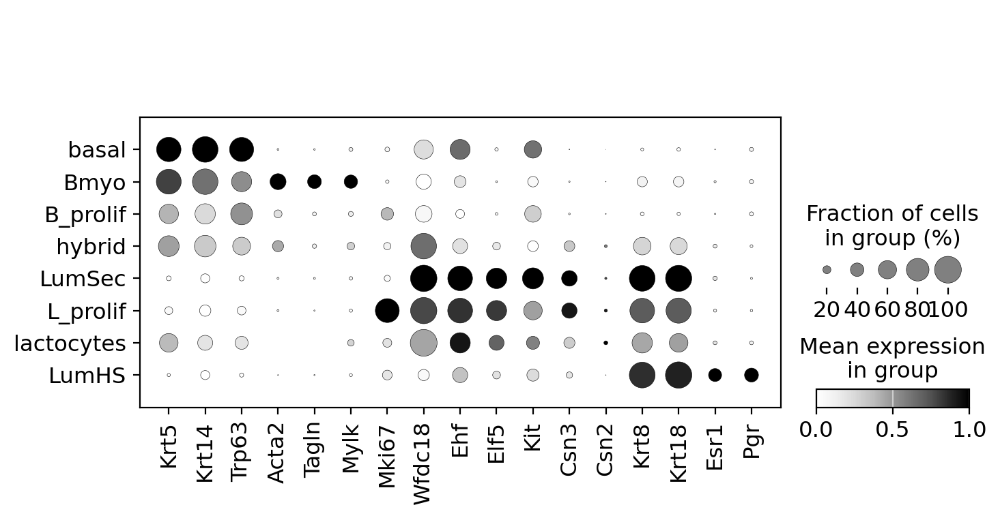

In [47]:
marker_genes = ["Krt5","Krt14","Trp63","Acta2","Tagln","Mylk","Mki67",
                "Wfdc18","Ehf","Elf5","Kit","Csn3","Csn2","Krt8","Krt18","Esr1","Pgr"]


sc.pl.dotplot(wap_tum, marker_genes, groupby="integrated_cell",
              standard_scale="var",swap_axes=False,cmap="Greys",
             categories_order=['basal','Bmyo','B_prolif',
              'hybrid','LumSec','L_prolif','lactocytes','LumHS'],
              save='wap_aneu_dot_canonical_integrated_cell.pdf'
             )

In [48]:
blg_tum = wap[wap.obs['orig.ident'].isin(["WKBR61.4dTM","WKBR75.4bTM"])]

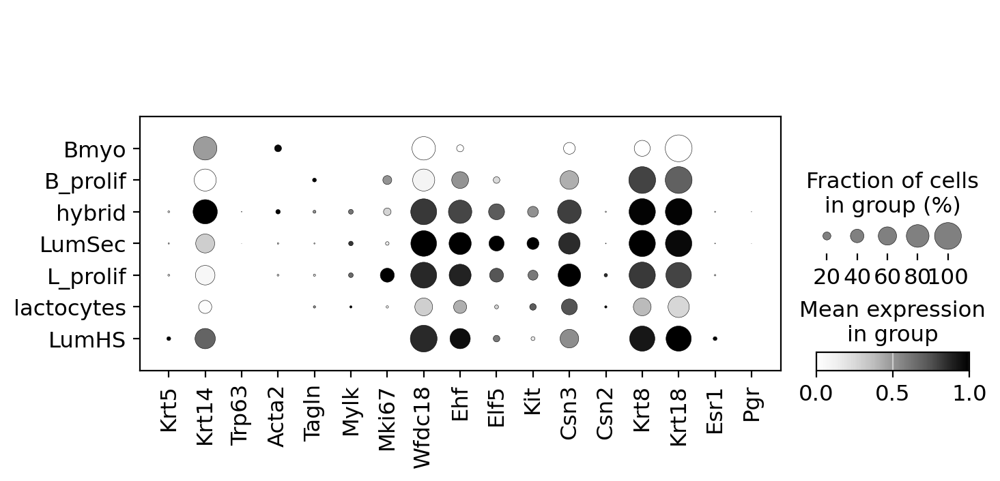

In [52]:
marker_genes = ["Krt5","Krt14","Trp63","Acta2","Tagln","Mylk","Mki67",
                "Wfdc18","Ehf","Elf5","Kit","Csn3","Csn2","Krt8","Krt18","Esr1","Pgr"]


sc.pl.dotplot(blg_tum, marker_genes, groupby="integrated_cell",
              standard_scale="var",swap_axes=False,cmap="Greys",
             categories_order=['Bmyo','B_prolif', #no 'basal'
              'hybrid','LumSec','L_prolif','lactocytes','LumHS'],
              save='blg_aneu_dot_canonical_integrated_cell.pdf'
             )

In [ ]:
1. add subtyping

2. rename idents (broad conditions)
3. make new idents (merge condition+celltype)
4. stacked bar of celltype-condition

In [32]:
res1 = pd.read_csv("/share/crsp/lab/dalawson/tzhuravl/CellPlex_Tumors/Scanpy_Seurat/scVI_epithelial/TNBC_subtyper/result_singlecell.csv")

#res1 = res1[res1['Unnamed: 0'].str.startswith('us')]
res1['Unnamed: 0'] = res1['Unnamed: 0'].str.replace('us_', '')
res1['Unnamed: 0'] = res1['Unnamed: 0'].str.replace('wk_', '')
res1['Unnamed: 0'] = res1['Unnamed: 0'].str.replace('vis_', '')
res1['Unnamed: 0'] = res1['Unnamed: 0'].str.replace('.', '-')

res1.set_index("Unnamed: 0", inplace=True)



res2 = pd.read_csv("/share/crsp/lab/dalawson/tzhuravl/CellPlex_Tumors/Scanpy_Seurat/scVI_epithelial/TNBC_subtyper/result_mouse_single_cell_lumhr_noESR.csv")

#res2 = res2[res2['Unnamed: 0'].str.startswith('us')]
res2['Unnamed: 0'] = res2['Unnamed: 0'].str.replace('us_', '')
res2['Unnamed: 0'] = res2['Unnamed: 0'].str.replace('wk_', '')
res2['Unnamed: 0'] = res2['Unnamed: 0'].str.replace('vis_', '')
res2['Unnamed: 0'] = res2['Unnamed: 0'].str.replace('.', '-')

res2.set_index("Unnamed: 0", inplace=True)



res3 = pd.read_csv("/share/crsp/lab/dalawson/tzhuravl/CellPlex_Tumors/Scanpy_Seurat/scVI_epithelial/TNBC_subtyper/result_mouse_single_cell_normal_epithelial_without_lumhr.csv")

#res3 = res3[res3['Unnamed: 0'].str.startswith('us')]
res3['Unnamed: 0'] = res3['Unnamed: 0'].str.replace('us_', '')
res3['Unnamed: 0'] = res3['Unnamed: 0'].str.replace('wk_', '')
res3['Unnamed: 0'] = res3['Unnamed: 0'].str.replace('vis_', '')
res3['Unnamed: 0'] = res3['Unnamed: 0'].str.replace('.', '-')

res3.set_index("Unnamed: 0", inplace=True)



res4 = pd.read_csv("/share/crsp/lab/dalawson/tzhuravl/CellPlex_Tumors/Scanpy_Seurat/scVI_epithelial/TNBC_subtyper/result_singlecell_basal_lumsec.csv")

res4['Unnamed: 0'] = res4['Unnamed: 0'].str.replace('.', '-')
res4.set_index("Unnamed: 0", inplace=True)



res = pd.concat([res1, res2, res3, res4], axis=0)

new_res = res[~res.index.duplicated(keep='first')]

#e18.obs['subtype'] = new_res['subtype']
full.obs['subtype'] = new_res['subtype']

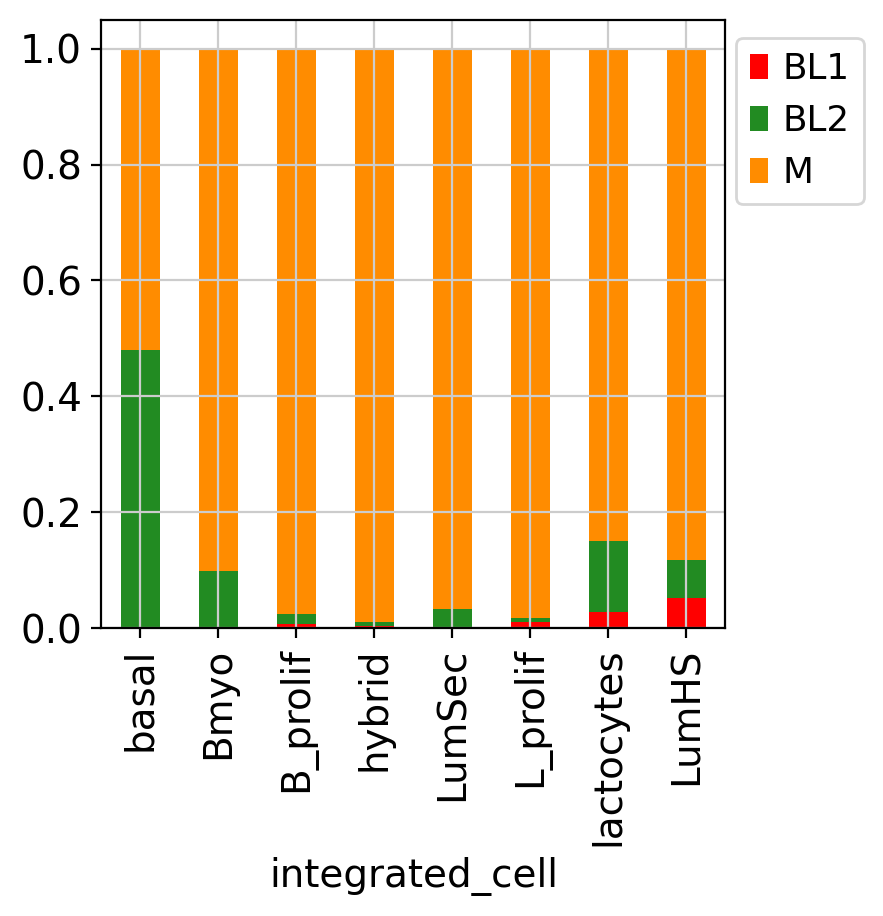

In [76]:
wap = e18[e18.obs['orig.ident'].isin(["E18-ME"])]

pl.rcParams["figure.figsize"] = (4,4)
tmp = pd.crosstab(wap.obs['subtype'],wap.obs['integrated_cell'], 
                  normalize='columns').reindex()[['basal','Bmyo','B_prolif',
              'hybrid','LumSec','L_prolif','lactocytes','LumHS']].T.plot(kind='bar', 
                                                                                            stacked=True,
                                                                                            color=['red','forestgreen','darkorange','grey'])
tmp.legend(title='', bbox_to_anchor=(1.25, 1.0),loc='upper right')

pl.savefig('Fig_5_E18_ident_integrated_cell_stackedbar_plot.pdf', bbox_inches='tight')

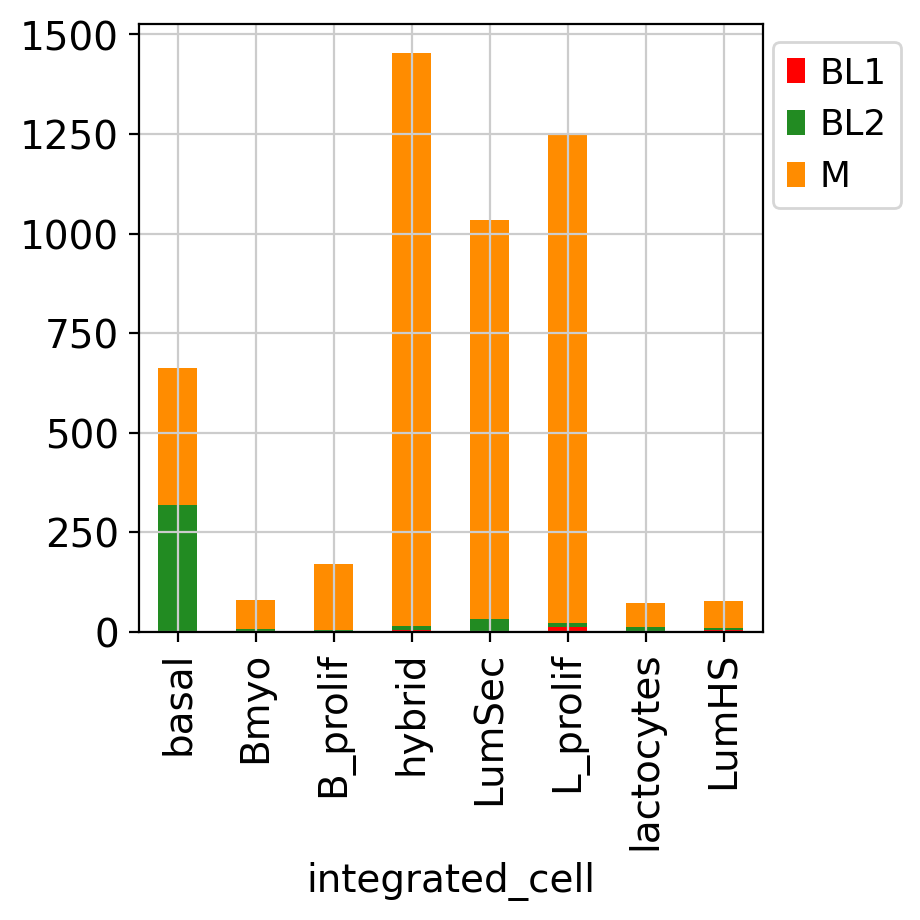

In [14]:
wap = e18[e18.obs['orig.ident'].isin(["E18-ME"])]

pl.rcParams["figure.figsize"] = (4,4)
tmp = pd.crosstab(wap.obs['subtype'],wap.obs['integrated_cell']).reindex()[['basal','Bmyo','B_prolif',
              'hybrid','LumSec','L_prolif','lactocytes','LumHS']].T.plot(kind='bar', 
                                                                                            stacked=True,
                                                                                            color=['red','forestgreen','darkorange','grey'])
tmp.legend(title='', bbox_to_anchor=(1.25, 1.0),loc='upper right')

pl.savefig('Fig_5_E18_ident_integrated_cell_stackedbar_plot.pdf', bbox_inches='tight')

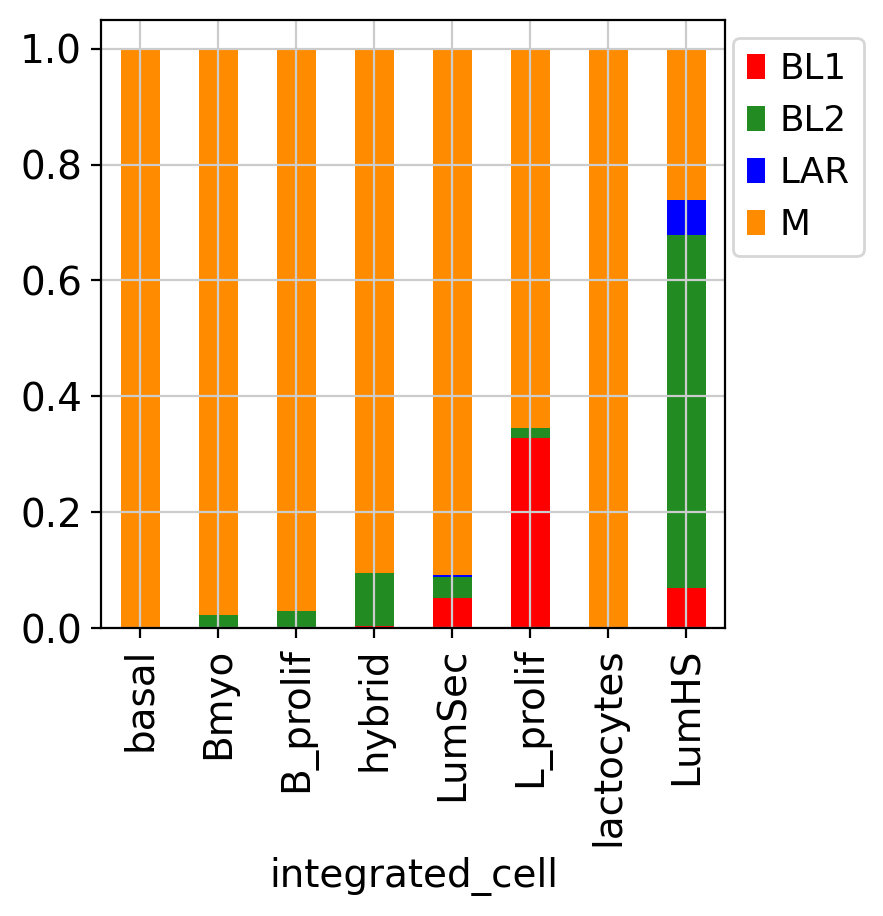

In [77]:
wap = e18[e18.obs['orig.ident'].isin(["nMFP_2","nMFP_3","nMFP_4","nMFP_5","nMFP_6","nMFP_7","nMFP_8","nMFP_10",
                                        "nMFP_11","nMFP_12","nMFP_13","nMFP_14","nMFP_15",
                                        "CTRL_1","CTRL_2","CTRL_3","Adult-BL6"])]

pl.rcParams["figure.figsize"] = (4,4)
tmp = pd.crosstab(wap.obs['subtype'],wap.obs['integrated_cell'], 
                  normalize='columns').reindex()[['basal','Bmyo','B_prolif',
              'hybrid','LumSec','L_prolif','lactocytes','LumHS']].T.plot(kind='bar', 
                                                                                            stacked=True,
                                                                                            color=['red','forestgreen','blue','darkorange','grey'])
tmp.legend(title='', bbox_to_anchor=(1.25, 1.0),loc='upper right')

pl.savefig('Fig_5_adult_ident_integrated_cell_stackedbar_plot.pdf', bbox_inches='tight')

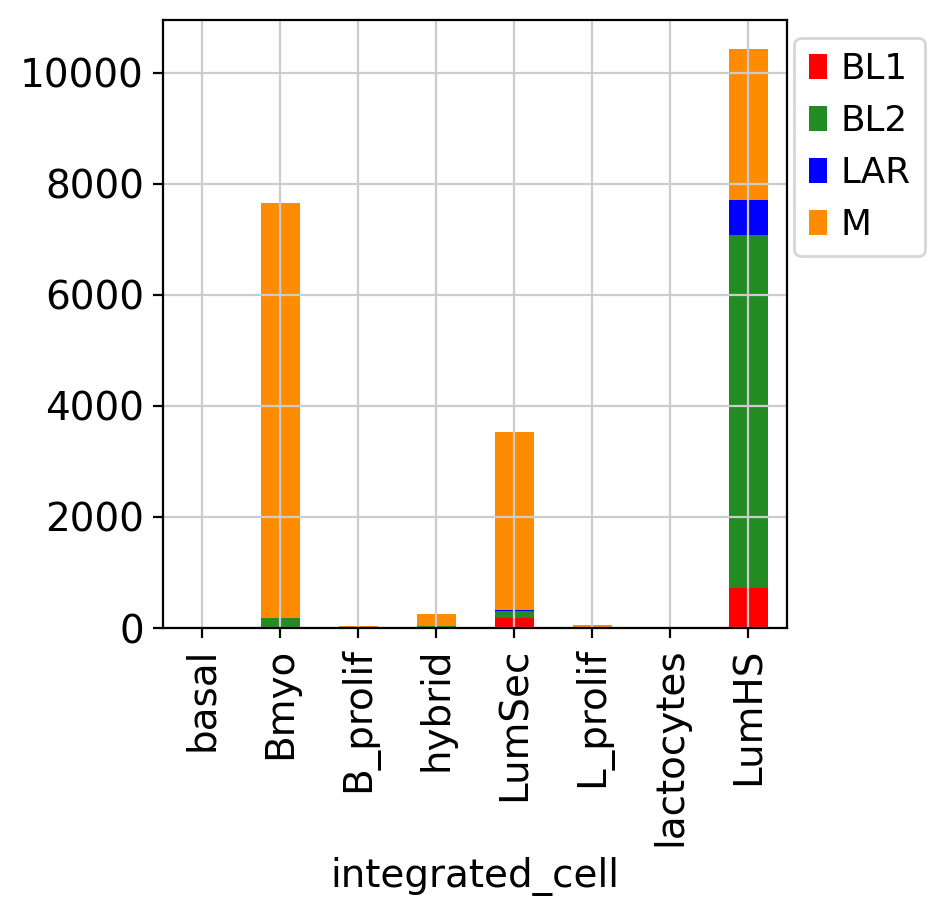

In [15]:
wap = e18[e18.obs['orig.ident'].isin(["nMFP_2","nMFP_3","nMFP_4","nMFP_5","nMFP_6","nMFP_7","nMFP_8","nMFP_10",
                                        "nMFP_11","nMFP_12","nMFP_13","nMFP_14","nMFP_15",
                                        "CTRL_1","CTRL_2","CTRL_3","Adult-BL6"])]

pl.rcParams["figure.figsize"] = (4,4)
tmp = pd.crosstab(wap.obs['subtype'],wap.obs['integrated_cell']).reindex()[['basal','Bmyo','B_prolif',
              'hybrid','LumSec','L_prolif','lactocytes','LumHS']].T.plot(kind='bar', 
                                                                                            stacked=True,
                                                                                            color=['red','forestgreen','blue','darkorange','grey'])
tmp.legend(title='', bbox_to_anchor=(1.25, 1.0),loc='upper right')

pl.savefig('Fig_5_adult_ident_integrated_cell_stackedbar_plot.pdf', bbox_inches='tight')

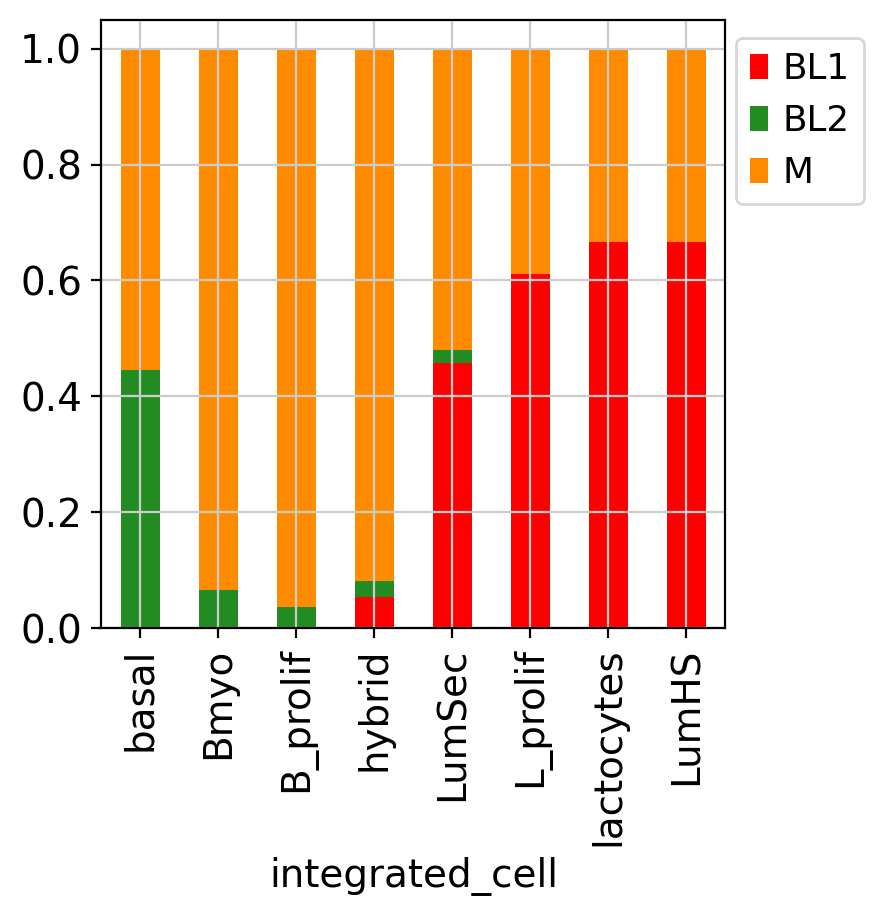

In [79]:
wap = e18[e18.obs['orig.ident'].isin(["pMFP_1","pMFP_2","pMFP_3","pMFP_4","pMFP_5","pMFP_6","pMFP_7","pMFP_8","pMFP_9","pMFP_10",
                                           "pMFP_11","pMFP_12","pMFP_13","pMFP_14","pMFP_15"])]

pl.rcParams["figure.figsize"] = (4,4)
tmp = pd.crosstab(wap.obs['subtype'],wap.obs['integrated_cell'], 
                  normalize='columns').reindex()[['basal','Bmyo','B_prolif',
              'hybrid','LumSec','L_prolif','lactocytes','LumHS']].T.plot(kind='bar', 
                                                                                            stacked=True,
                                                                                            color=['red','forestgreen','darkorange','grey'])
tmp.legend(title='', bbox_to_anchor=(1.25, 1.0),loc='upper right')

pl.savefig('Fig_5_wap_aneu_ident_integrated_cell_stackedbar_plot.pdf', bbox_inches='tight')

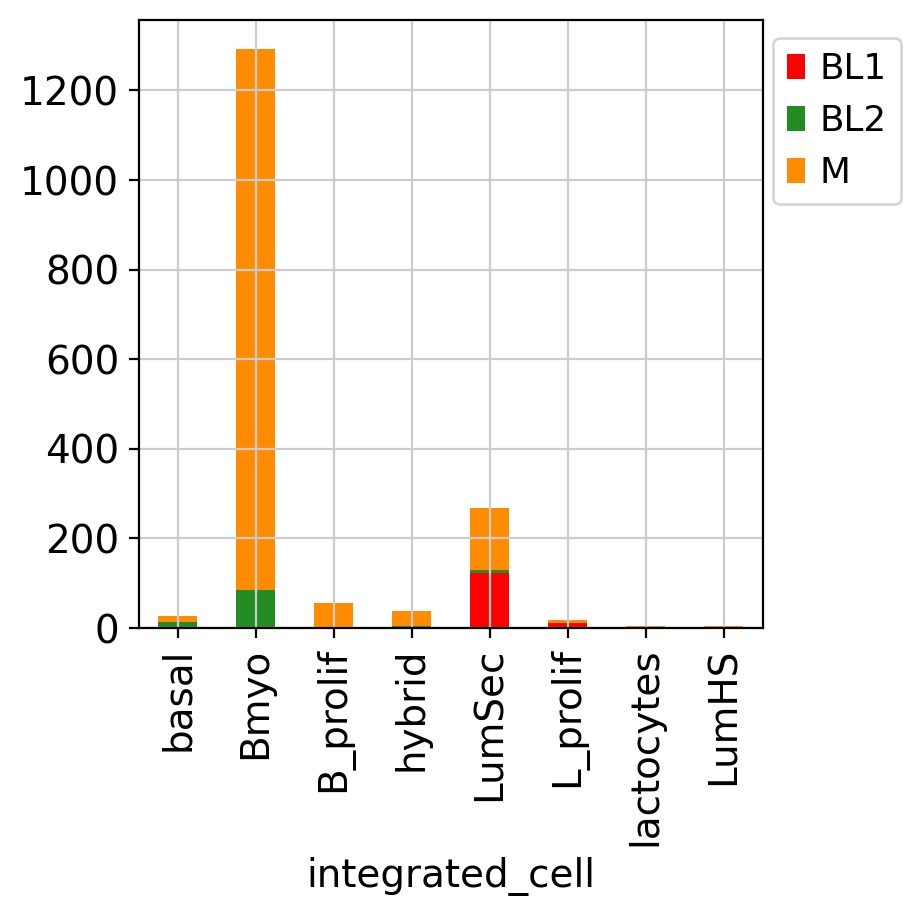

In [16]:
wap = e18[e18.obs['orig.ident'].isin(["pMFP_1","pMFP_2","pMFP_3","pMFP_4","pMFP_5","pMFP_6","pMFP_7","pMFP_8","pMFP_9","pMFP_10",
                                           "pMFP_11","pMFP_12","pMFP_13","pMFP_14","pMFP_15"])]

pl.rcParams["figure.figsize"] = (4,4)
tmp = pd.crosstab(wap.obs['subtype'],wap.obs['integrated_cell']).reindex()[['basal','Bmyo','B_prolif',
              'hybrid','LumSec','L_prolif','lactocytes','LumHS']].T.plot(kind='bar', 
                                                                                            stacked=True,
                                                                                            color=['red','forestgreen','darkorange','grey'])
tmp.legend(title='', bbox_to_anchor=(1.25, 1.0),loc='upper right')

pl.savefig('Fig_5_wap_aneu_ident_integrated_cell_stackedbar_plot.pdf', bbox_inches='tight')

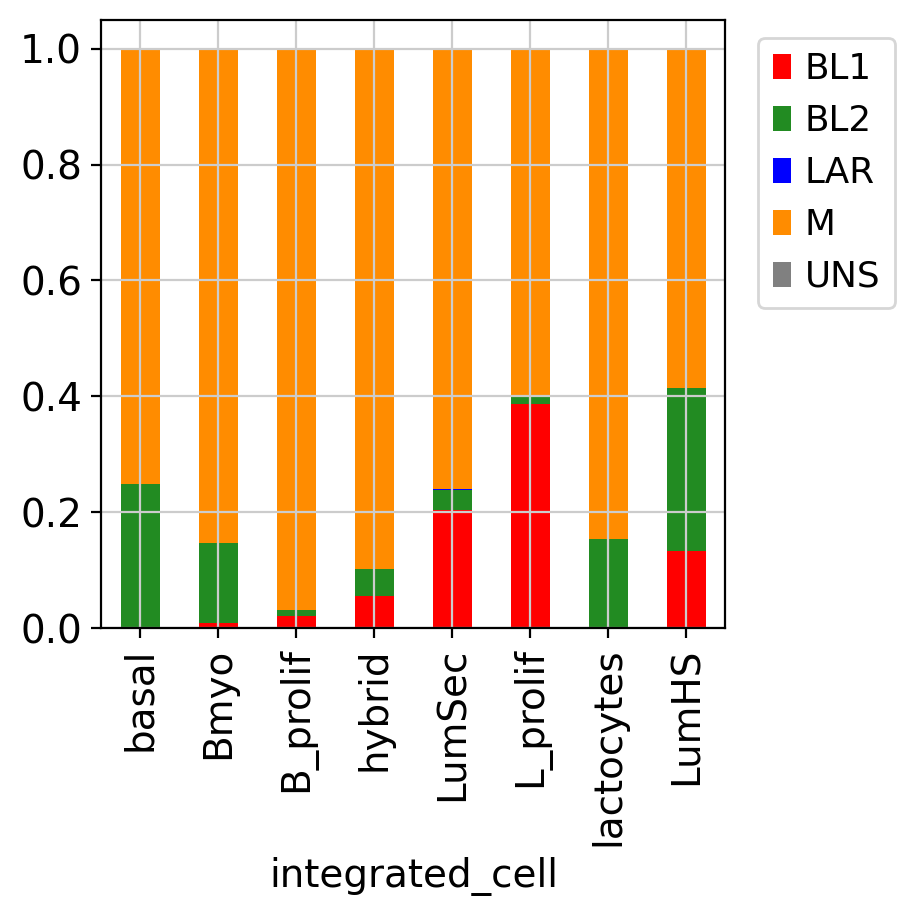

In [80]:
wap = e18[e18.obs['orig.ident'].isin(["tum_599",
                                          "tum_633",
                                          "tum_081720",
                                          "tum_111121",
                                          "tum_111121_enr",
                                          "tum_966",
                                          "tum_or_pMFP_654",
                                          "tum_120519"])]

pl.rcParams["figure.figsize"] = (4,4)
tmp = pd.crosstab(wap.obs['subtype'],wap.obs['integrated_cell'], 
                  normalize='columns').reindex()[['basal','Bmyo','B_prolif',
              'hybrid','LumSec','L_prolif','lactocytes','LumHS']].T.plot(kind='bar', 
                                                                                            stacked=True,
                                                                                            color=['red','forestgreen','blue','darkorange','grey'])
tmp.legend(title='', bbox_to_anchor=(1.3, 1.0),loc='upper right')

pl.savefig('Fig_5_wap_aneu_tum_ident_integrated_cell_stackedbar_plot.pdf', bbox_inches='tight')

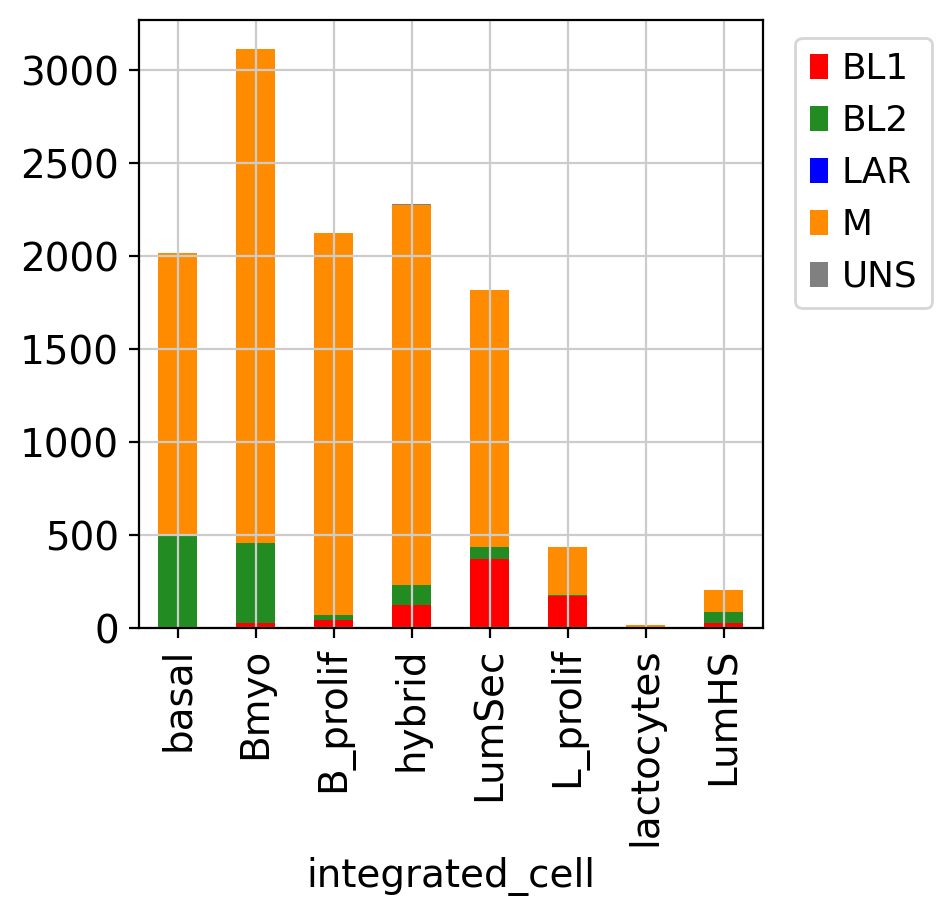

In [17]:
wap = e18[e18.obs['orig.ident'].isin(["tum_599",
                                          "tum_633",
                                          "tum_081720",
                                          "tum_111121",
                                          "tum_111121_enr",
                                          "tum_966",
                                          "tum_or_pMFP_654",
                                          "tum_120519"])]

pl.rcParams["figure.figsize"] = (4,4)
tmp = pd.crosstab(wap.obs['subtype'],wap.obs['integrated_cell']).reindex()[['basal','Bmyo','B_prolif',
              'hybrid','LumSec','L_prolif','lactocytes','LumHS']].T.plot(kind='bar', 
                                                                                            stacked=True,
                                                                                            color=['red','forestgreen','blue','darkorange','grey'])
tmp.legend(title='', bbox_to_anchor=(1.3, 1.0),loc='upper right')

pl.savefig('Fig_5_wap_aneu_tum_ident_integrated_cell_stackedbar_plot.pdf', bbox_inches='tight')

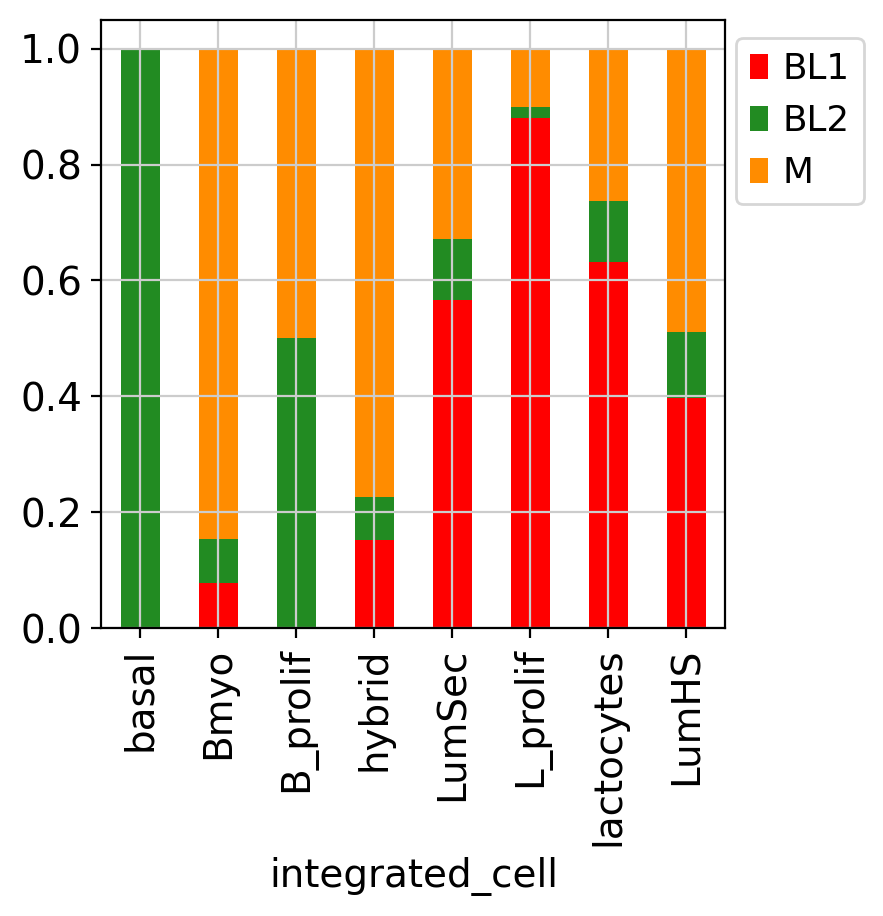

In [81]:
wap = e18[e18.obs['orig.ident'].isin(["WKBR65.2f","WKBR65.2g","WKBR91.1f",
                                            "WKBR90.3i","WKBR91.1e","WKBR65.3h","WKBR90.3g",
                                           "WKBR65.3g","WKBR76.4f","WKBR65.3i","WKBR91.3j",
                                       "WKBR61.4dMG","WKBR75.4bMG"])]

pl.rcParams["figure.figsize"] = (4,4)
tmp = pd.crosstab(wap.obs['subtype'],wap.obs['integrated_cell'], 
                  normalize='columns').reindex()[['basal','Bmyo','B_prolif',
              'hybrid','LumSec','L_prolif','lactocytes','LumHS']].T.plot(kind='bar', 
                                                                                            stacked=True,
                                                                                            color=['red','forestgreen','darkorange','grey'])
tmp.legend(title='', bbox_to_anchor=(1.25, 1.0),loc='upper right')

pl.savefig('Fig_5_blg_aneu_ident_integrated_cell_stackedbar_plot.pdf', bbox_inches='tight')

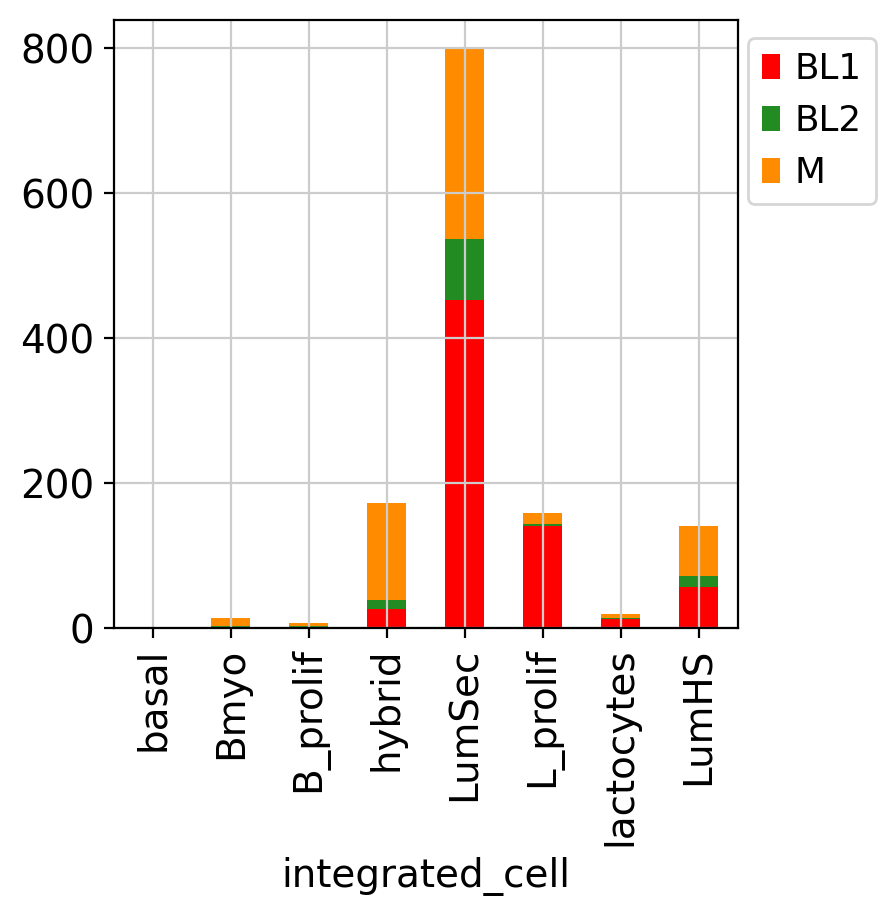

In [18]:
wap = e18[e18.obs['orig.ident'].isin(["WKBR65.2f","WKBR65.2g","WKBR91.1f",
                                            "WKBR90.3i","WKBR91.1e","WKBR65.3h","WKBR90.3g",
                                           "WKBR65.3g","WKBR76.4f","WKBR65.3i","WKBR91.3j",
                                       "WKBR61.4dMG","WKBR75.4bMG"])]

pl.rcParams["figure.figsize"] = (4,4)
tmp = pd.crosstab(wap.obs['subtype'],wap.obs['integrated_cell']).reindex()[['basal','Bmyo','B_prolif',
              'hybrid','LumSec','L_prolif','lactocytes','LumHS']].T.plot(kind='bar', 
                                                                                            stacked=True,
                                                                                            color=['red','forestgreen','darkorange','grey'])
tmp.legend(title='', bbox_to_anchor=(1.25, 1.0),loc='upper right')

pl.savefig('Fig_5_blg_aneu_ident_integrated_cell_stackedbar_plot.pdf', bbox_inches='tight')

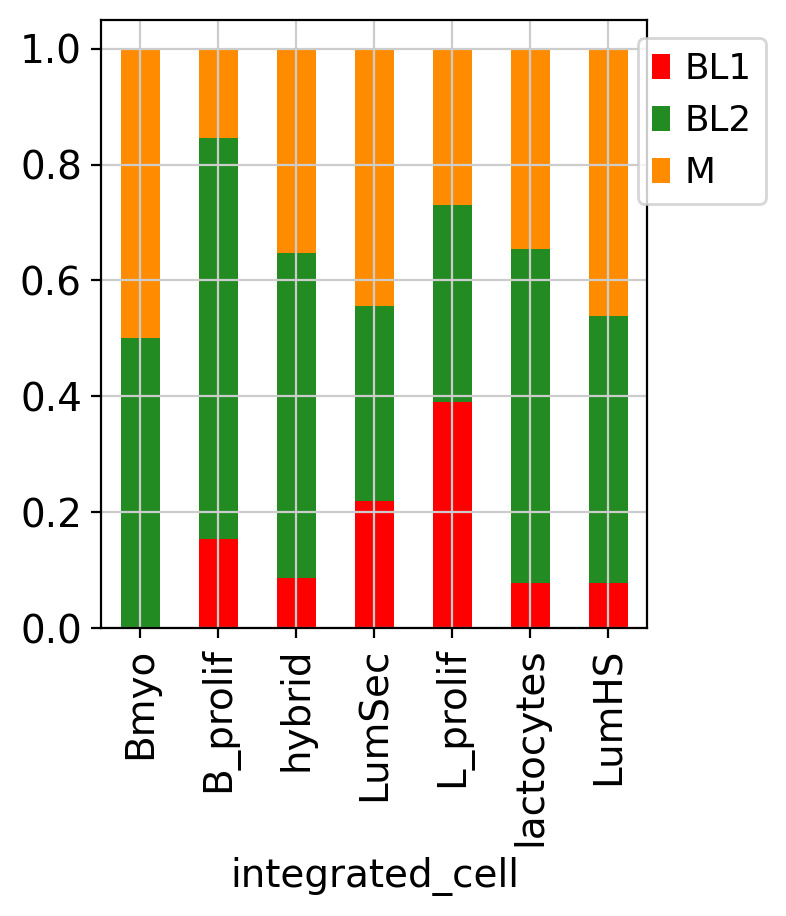

In [83]:
wap = e18[e18.obs['orig.ident'].isin(["WKBR61.4dTM","WKBR75.4bTM"])]

pl.rcParams["figure.figsize"] = (3.5,4)
tmp = pd.crosstab(wap.obs['subtype'],wap.obs['integrated_cell'], 
                  normalize='columns').reindex()[['Bmyo','B_prolif',
              'hybrid','LumSec','L_prolif','lactocytes','LumHS']].T.plot(kind='bar', 
                                                                                            stacked=True,
                                                                                            color=['red','forestgreen','darkorange','grey'])
tmp.legend(title='', bbox_to_anchor=(1.25, 1.0),loc='upper right')

pl.savefig('Fig_5_blg_aneu_tum_ident_integrated_cell_stackedbar_plot.pdf', bbox_inches='tight')

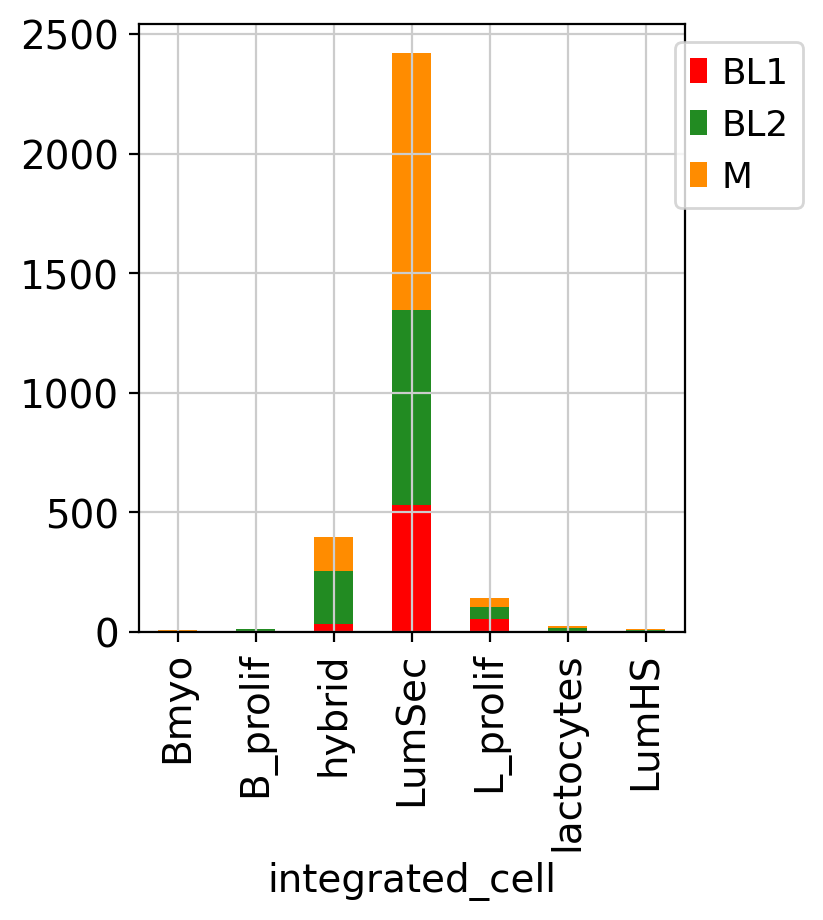

In [19]:
wap = e18[e18.obs['orig.ident'].isin(["WKBR61.4dTM","WKBR75.4bTM"])]

pl.rcParams["figure.figsize"] = (3.5,4)
tmp = pd.crosstab(wap.obs['subtype'],wap.obs['integrated_cell']).reindex()[['Bmyo','B_prolif',
              'hybrid','LumSec','L_prolif','lactocytes','LumHS']].T.plot(kind='bar', 
                                                                                            stacked=True,
                                                                                            color=['red','forestgreen','darkorange','grey'])
tmp.legend(title='', bbox_to_anchor=(1.25, 1.0),loc='upper right')

pl.savefig('Fig_5_blg_aneu_tum_ident_integrated_cell_stackedbar_plot.pdf', bbox_inches='tight')

In [90]:
e18.obs['Fig_5_ident'] = (
    e18.obs["orig.ident"]
    .map(lambda x: {"E18-ME": "Embryonic Day 18",
                    "Pre-D5-BL6": "Postnatal Day 5",
                    "nMFP_2": "Adult Week 19",
                    "nMFP_3": "Adult Week 19",
                    "nMFP_4": "Adult Week 19",
                    "nMFP_5": "Adult Week 19",
                    "nMFP_6": "Adult Week 19",
                    "nMFP_7": "Adult Week 19",
                    "nMFP_8": "Adult Week 19",
                    "nMFP_10": "Adult Week 19",
                    "nMFP_11": "Adult Week 19",
                    "nMFP_12": "Adult Week 19",
                    "nMFP_13": "Adult Week 19",
                    "nMFP_14": "Adult Week 19",
                    "nMFP_15": "Adult Week 19",
                    "CTRL_1": "Adult Week 12",
                    "CTRL_2": "Adult Week 12",
                    "CTRL_3": "Adult Week 12",
                    "Adult-BL6": "Adult Week 10",
                    "pMFP_1": "WAP-Cre aneuploid 1",
                    "pMFP_2": "WAP-Cre aneuploid 2",
                    "pMFP_3": "WAP-Cre aneuploid 3",
                    "pMFP_4": "WAP-Cre aneuploid 4",
                    "pMFP_5": "WAP-Cre aneuploid 5",
                    "pMFP_6": "WAP-Cre aneuploid 6",
                    "pMFP_7": "WAP-Cre aneuploid 7",
                    "pMFP_8": "WAP-Cre aneuploid 8",
                    "pMFP_9": "WAP-Cre aneuploid 9",
                    "pMFP_10": "WAP-Cre aneuploid 10",
                    "pMFP_11": "WAP-Cre aneuploid 11",
                    "pMFP_12": "WAP-Cre aneuploid 12",
                    "pMFP_13": "WAP-Cre aneuploid 13",
                    "pMFP_14": "WAP-Cre aneuploid 14",
                    "pMFP_15": "WAP-Cre aneuploid 15",
                    "tum_599": "WAP-Cre aneuploid tumor 4",
                    "tum_633": "WAP-Cre aneuploid tumor 3",
                    "tum_081720": "WAP-Cre aneuploid tumor 6",
                    "tum_111121": "WAP-Cre aneuploid tumor 5",
                    "tum_111121_enr": "WAP-Cre aneuploid tumor 5",
                    "tum_966": "WAP-Cre aneuploid tumor 2",
                    "tum_or_pMFP_654": "WAP-Cre aneuploid tumor 1",
                    "tum_120519": "WAP-Cre aneuploid tumor 7",
                    "WKBR65.2f": "Blg-Cre aneuploid 1",
                    "WKBR65.2g": "Blg-Cre aneuploid 2",
                    "WKBR91.1f": "Blg-Cre aneuploid 9",
                    "WKBR90.3i": "Blg-Cre aneuploid 8",
                    "WKBR91.1e": "Blg-Cre aneuploid 10",
                    "WKBR65.3h": "Blg-Cre aneuploid 4",
                    "WKBR90.3g": "Blg-Cre aneuploid 7",
                    "WKBR65.3g": "Blg-Cre aneuploid 3",
                    "WKBR76.4f": "Blg-Cre aneuploid 6",
                    "WKBR65.3i": "Blg-Cre aneuploid 5",
                    "WKBR91.3j": "Blg-Cre aneuploid 11",
                    "WKBR61.4dMG": "Blg-Cre aneuploid 12",
                    "WKBR75.4bMG": "Blg-Cre aneuploid 13",
                    "WKBR61.4dTM": "Blg-Cre aneuploid tumor 1",
                    "WKBR75.4bTM": "Blg-Cre aneuploid tumor 2",
                   "E18-Skin": "Embryonic Day 18 skin",
                    "Pre-BL6": "Prepuberty Week 2",
                    "Duct": "Puberty Week 5 Duct",
                    "TEB": "Puberty Week 5 TEB",
                    "Preg-D12": "Pregnancy Day 12",
                    "Preg-D12-G": "Pregnancy Day 12",
                    "Preg-D18": "Pregnancy Day 18",
                    "Preg-D18-B4": "Pregnancy Day 18",
                    "Lac-D10": "Lactation Day 10",
                    "Lac-D10-D6": "Lactation Day 10",
                    "PI-W3": "Post-involution Day 21"}.get(x, x))
    .astype("category")
)

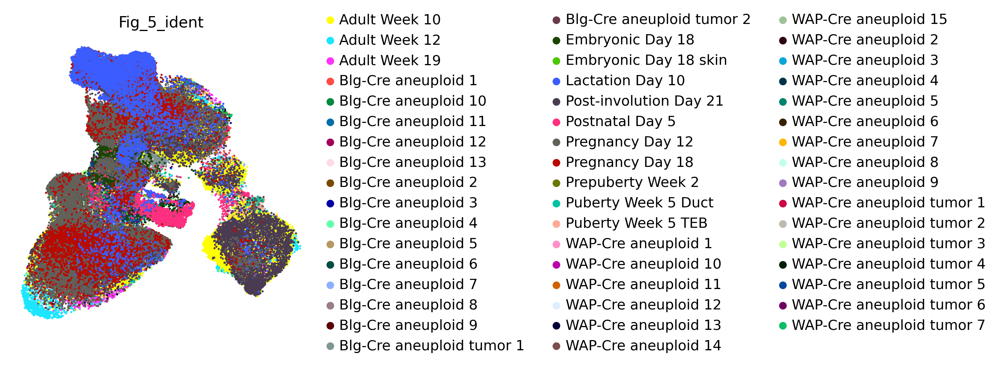

In [91]:
sc.pl.umap(
    e18,
    color=["Fig_5_ident"],
    frameon=False,
    ncols=1,s=15,
    #palette=['black', '#27AAE1','blue','darkorange','navajowhite','#da8bc3',
                         #'grey','#2ca02c']
)

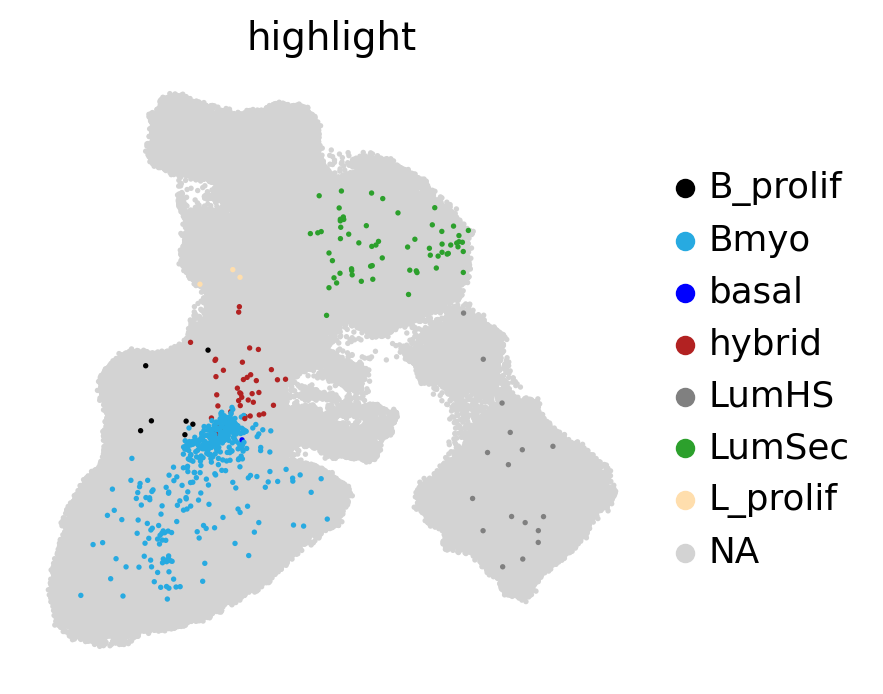

In [5]:
e18 = full[full.obs['orig.ident'].isin(["tum_or_pMFP_654"])]
full.obs['highlight'] = e18.obs['integrated_cell']

#pl.rcParams["figure.figsize"] = (5,5)
sc.pl.umap(
    full,
    color=["highlight"],
    frameon=False,
    ncols=1,
    size=15,
    palette=['black', '#27AAE1','blue','firebrick','grey','#2ca02c','navajowhite','#da8bc3',
                         ],
)

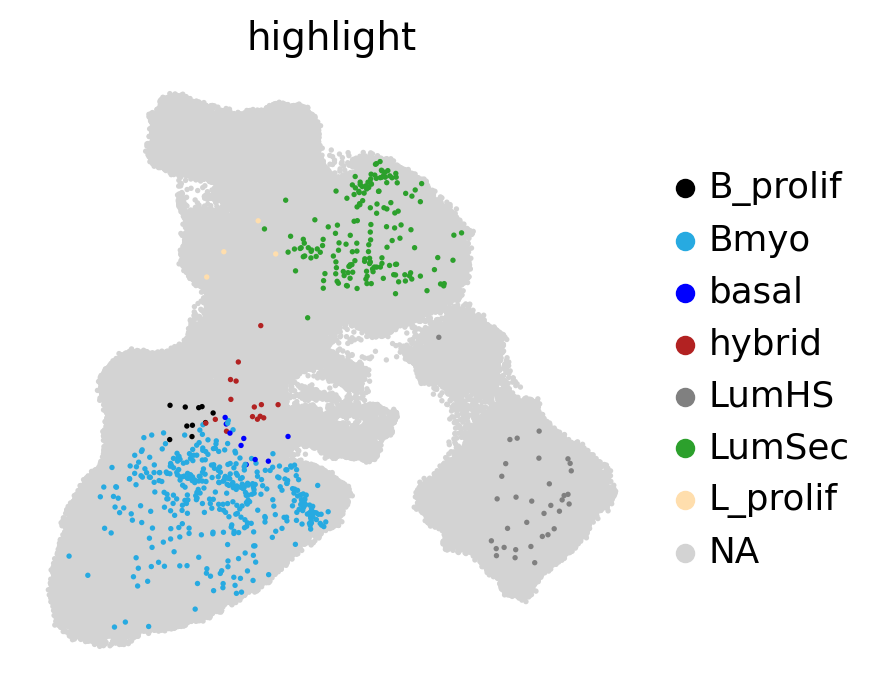

In [6]:
e18 = full[full.obs['orig.ident'].isin(["tum_966"])]
full.obs['highlight'] = e18.obs['integrated_cell']

#pl.rcParams["figure.figsize"] = (5,5)
sc.pl.umap(
    full,
    color=["highlight"],
    frameon=False,
    ncols=1,
    size=15,
    palette=['black', '#27AAE1','blue','firebrick','grey','#2ca02c','navajowhite','#da8bc3',
                         ],
)

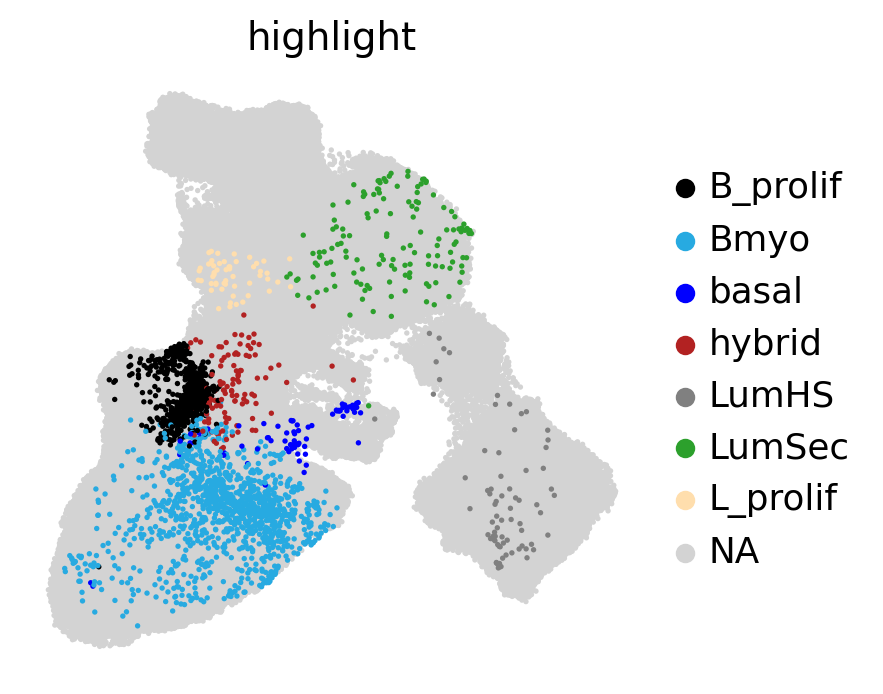

In [7]:
e18 = full[full.obs['orig.ident'].isin(["tum_633"])]
full.obs['highlight'] = e18.obs['integrated_cell']

#pl.rcParams["figure.figsize"] = (5,5)
sc.pl.umap(
    full,
    color=["highlight"],
    frameon=False,
    ncols=1,
    size=15,
    palette=['black', '#27AAE1','blue','firebrick','grey','#2ca02c','navajowhite','#da8bc3',
                         ],
)

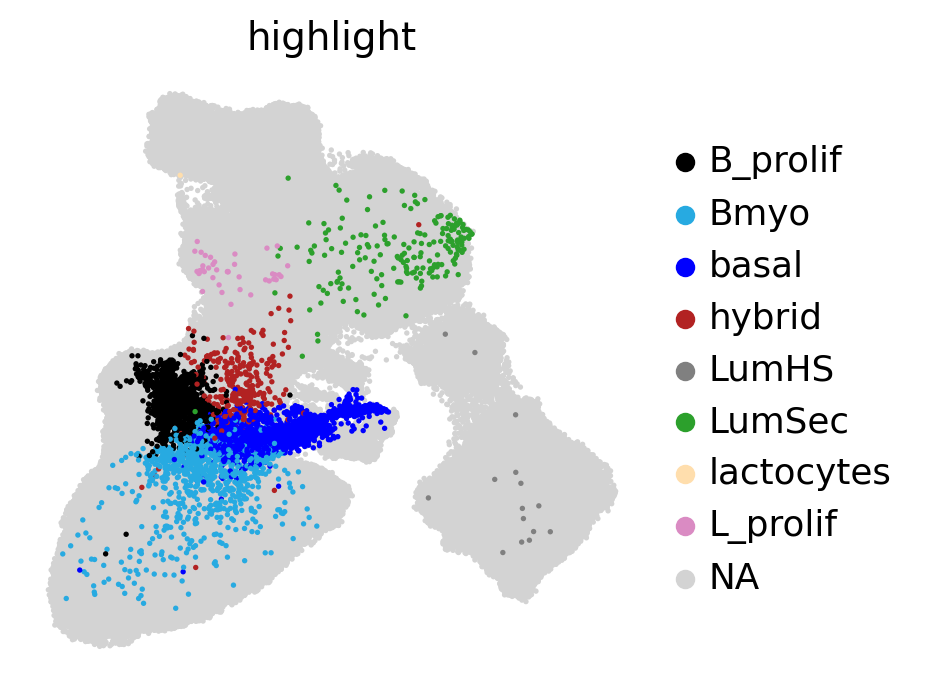

In [8]:
e18 = full[full.obs['orig.ident'].isin(["tum_599"])]
full.obs['highlight'] = e18.obs['integrated_cell']

#pl.rcParams["figure.figsize"] = (5,5)
sc.pl.umap(
    full,
    color=["highlight"],
    frameon=False,
    ncols=1,
    size=15,
    palette=['black', '#27AAE1','blue','firebrick','grey','#2ca02c','navajowhite','#da8bc3',
                         ],
)

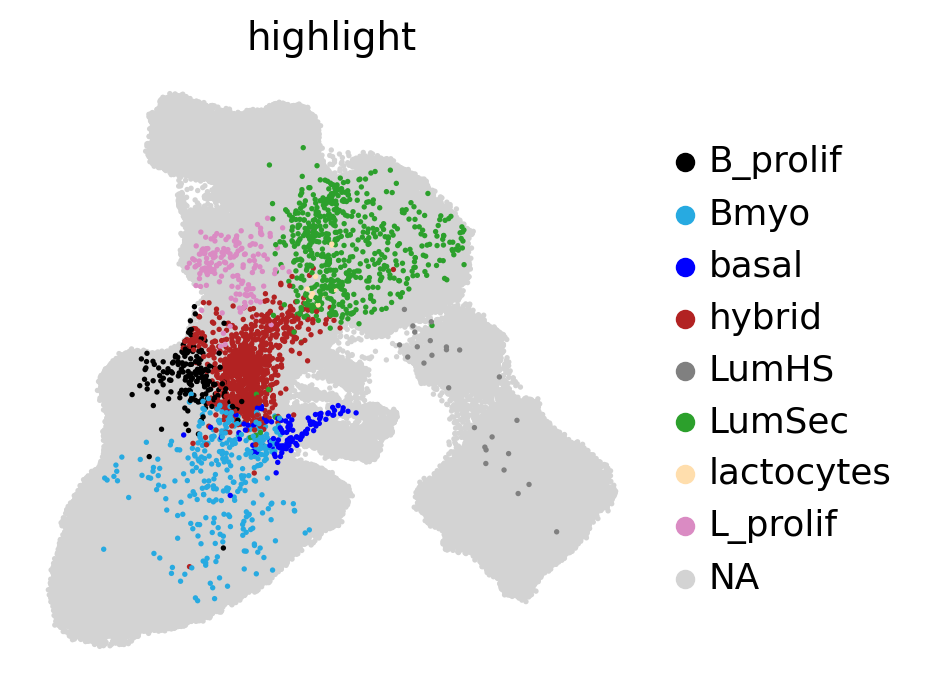

In [9]:
e18 = full[full.obs['orig.ident'].isin(["tum_111121","tum_111121_enr"])]
full.obs['highlight'] = e18.obs['integrated_cell']

#pl.rcParams["figure.figsize"] = (5,5)
sc.pl.umap(
    full,
    color=["highlight"],
    frameon=False,
    ncols=1,
    size=15,
    palette=['black', '#27AAE1','blue','firebrick','grey','#2ca02c','navajowhite','#da8bc3',
                         ],
)

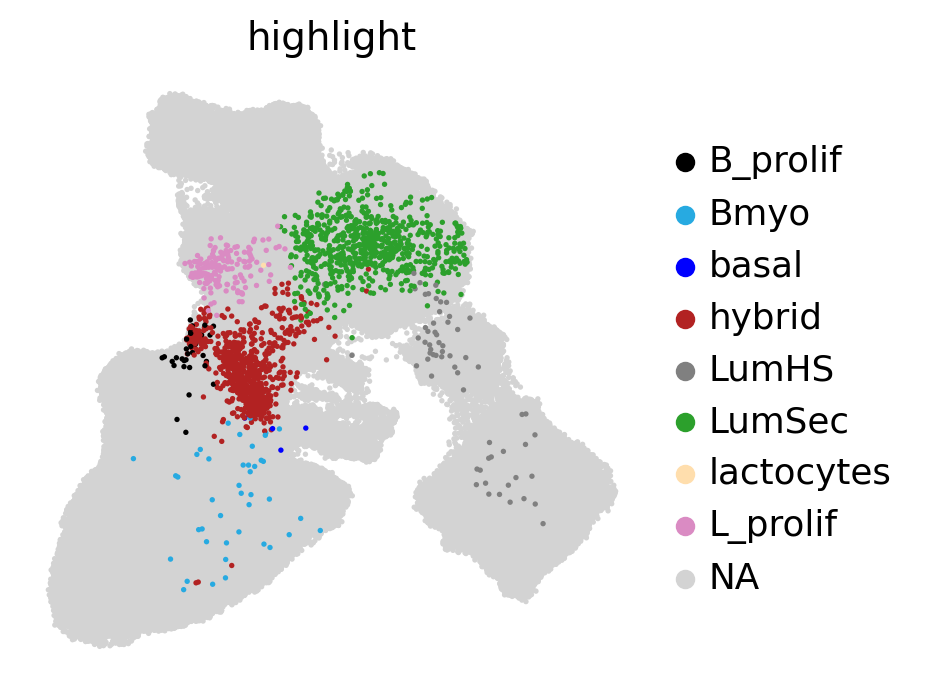

In [11]:
e18 = full[full.obs['orig.ident'].isin(["tum_081720"])]
full.obs['highlight'] = e18.obs['integrated_cell']

#pl.rcParams["figure.figsize"] = (5,5)
sc.pl.umap(
    full,
    color=["highlight"],
    frameon=False,
    ncols=1,
    size=15,
    palette=['black', '#27AAE1','blue','firebrick','grey','#2ca02c','navajowhite','#da8bc3',
                         ],
)

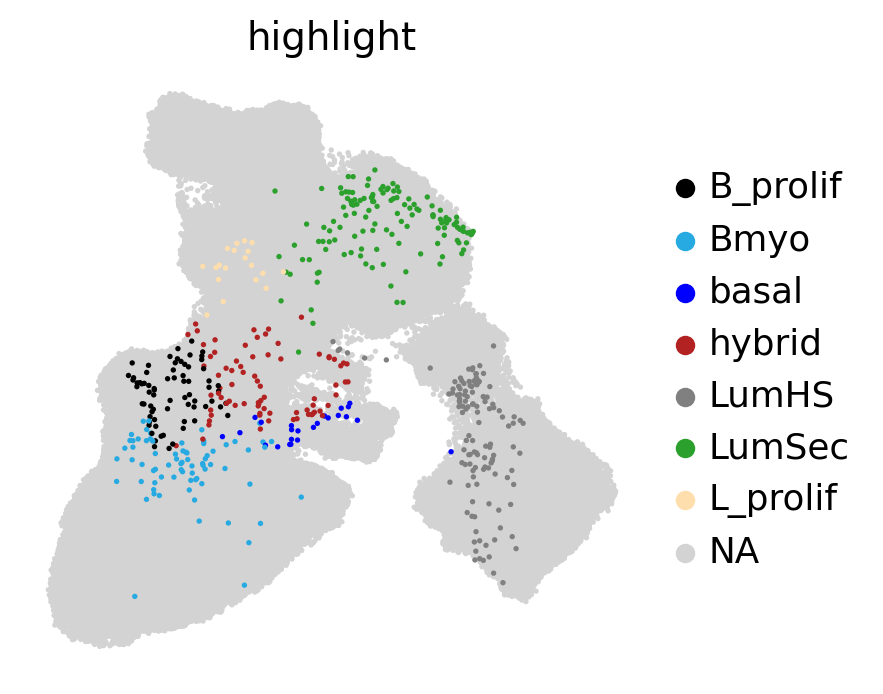

In [12]:
e18 = full[full.obs['orig.ident'].isin(["tum_120519"])]
full.obs['highlight'] = e18.obs['integrated_cell']

#pl.rcParams["figure.figsize"] = (5,5)
sc.pl.umap(
    full,
    color=["highlight"],
    frameon=False,
    ncols=1,
    size=15,
    palette=['black', '#27AAE1','blue','firebrick','grey','#2ca02c','navajowhite','#da8bc3',
                         ],
)

## mets

In [21]:
full.obs['dataset'].value_counts()

dataset
development    95483
wap_cre        44109
blg_cre        37714
Name: count, dtype: int64

In [27]:
sub = full[full.obs['dataset'].isin(["wap_cre"])]
sub = sub[sub.obs['orig.ident'].isin(["tum_111121","tum_111121_enr","tum_ortho_colIV","tum_ortho_colD","brain_1",
                                     "lung_1","lung_2","lung_3","lung_4",
                                     "liver_1","liver_2","liver_3","liver_4"])]

In [6]:
res1 = pd.read_csv("/share/crsp/lab/dalawson/tzhuravl/CellPlex_Tumors/Scanpy_Seurat/scVI_epithelial/TNBC_subtyper/result_singlecell.csv")

#res1 = res1[res1['Unnamed: 0'].str.startswith('us')]
res1['Unnamed: 0'] = res1['Unnamed: 0'].str.replace('us_', '')
res1['Unnamed: 0'] = res1['Unnamed: 0'].str.replace('wk_', '')
res1['Unnamed: 0'] = res1['Unnamed: 0'].str.replace('vis_', '')
res1['Unnamed: 0'] = res1['Unnamed: 0'].str.replace('.', '-')

res1.set_index("Unnamed: 0", inplace=True)



res2 = pd.read_csv("/share/crsp/lab/dalawson/tzhuravl/CellPlex_Tumors/Scanpy_Seurat/scVI_epithelial/TNBC_subtyper/result_mouse_single_cell_lumhr_noESR.csv")

#res2 = res2[res2['Unnamed: 0'].str.startswith('us')]
res2['Unnamed: 0'] = res2['Unnamed: 0'].str.replace('us_', '')
res2['Unnamed: 0'] = res2['Unnamed: 0'].str.replace('wk_', '')
res2['Unnamed: 0'] = res2['Unnamed: 0'].str.replace('vis_', '')
res2['Unnamed: 0'] = res2['Unnamed: 0'].str.replace('.', '-')

res2.set_index("Unnamed: 0", inplace=True)



res3 = pd.read_csv("/share/crsp/lab/dalawson/tzhuravl/CellPlex_Tumors/Scanpy_Seurat/scVI_epithelial/TNBC_subtyper/result_mouse_single_cell_normal_epithelial_without_lumhr.csv")

#res3 = res3[res3['Unnamed: 0'].str.startswith('us')]
res3['Unnamed: 0'] = res3['Unnamed: 0'].str.replace('us_', '')
res3['Unnamed: 0'] = res3['Unnamed: 0'].str.replace('wk_', '')
res3['Unnamed: 0'] = res3['Unnamed: 0'].str.replace('vis_', '')
res3['Unnamed: 0'] = res3['Unnamed: 0'].str.replace('.', '-')

res3.set_index("Unnamed: 0", inplace=True)



res4 = pd.read_csv("/share/crsp/lab/dalawson/tzhuravl/CellPlex_Tumors/Scanpy_Seurat/scVI_epithelial/TNBC_subtyper/result_singlecell_basal_lumsec.csv")

res4['Unnamed: 0'] = res4['Unnamed: 0'].str.replace('.', '-')
res4.set_index("Unnamed: 0", inplace=True)



res = pd.concat([res1, res2, res3, res4], axis=0)

new_res = res[~res.index.duplicated(keep='first')]

sub.obs['subtype'] = new_res['subtype']

/tmp/ipykernel_3239986/993205848.py:48: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  sub.obs['subtype'] = new_res['subtype']


In [38]:
sub.obs['orig.ident'].value_counts()

orig.ident
tum_111121         1616
tum_ortho_colIV    1543
tum_111121_enr      757
tum_ortho_colD      576
lung_3              379
lung_4              378
liver_4             357
lung_2              244
liver_1             198
brain_1             168
lung_1              134
liver_3              43
liver_2              29
Name: count, dtype: int64

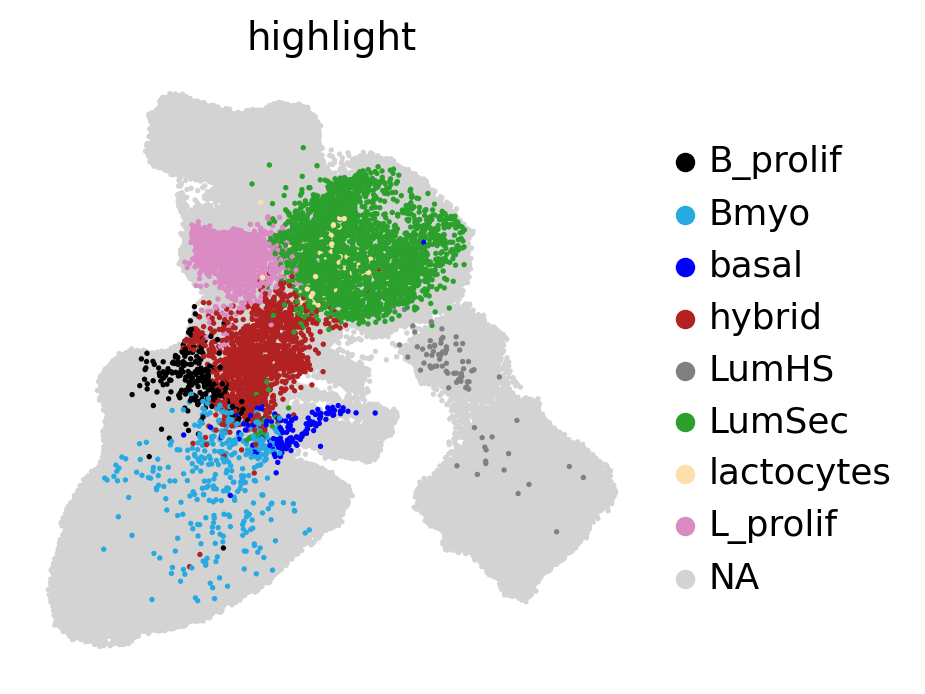

In [10]:
full.obs['highlight'] = sub.obs['integrated_cell']

#pl.rcParams["figure.figsize"] = (5,5)
sc.pl.umap(
    full,
    color=["highlight"],
    frameon=False,
    ncols=1,
    size=15,
    palette=['black', '#27AAE1','blue','firebrick','grey','#2ca02c','navajowhite','#da8bc3',
                         ],
    save='_primary_mets.pdf',
)

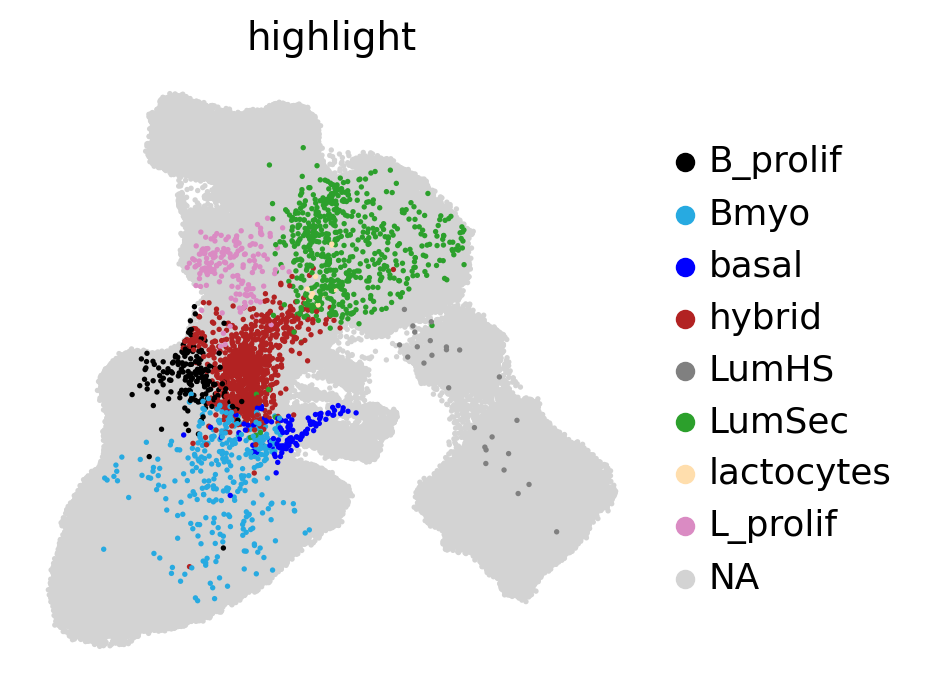

In [14]:
met = sub[sub.obs['orig.ident'].isin(["tum_111121","tum_111121_enr"])]
full.obs['highlight'] = met.obs['integrated_cell']

#pl.rcParams["figure.figsize"] = (5,5)
sc.pl.umap(
    full,
    color=["highlight"],
    frameon=False,
    ncols=1,
    size=15,
    palette=['black', '#27AAE1','blue','firebrick','grey','#2ca02c','navajowhite','#da8bc3',
                         ],
)

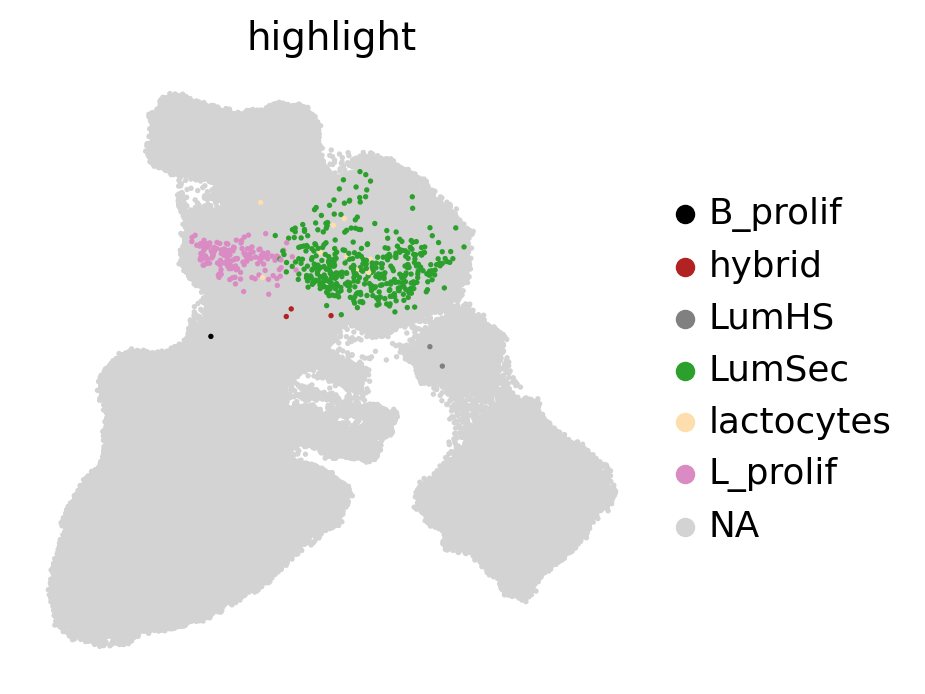

In [17]:
met = sub[sub.obs['orig.ident'].isin(["tum_ortho_colD"])]
full.obs['highlight'] = met.obs['integrated_cell']

#pl.rcParams["figure.figsize"] = (5,5)
sc.pl.umap(
    full,
    color=["highlight"],
    frameon=False,
    ncols=1,
    size=15,
    palette=['black','firebrick','grey','#2ca02c','navajowhite','#da8bc3',
                         ],
)

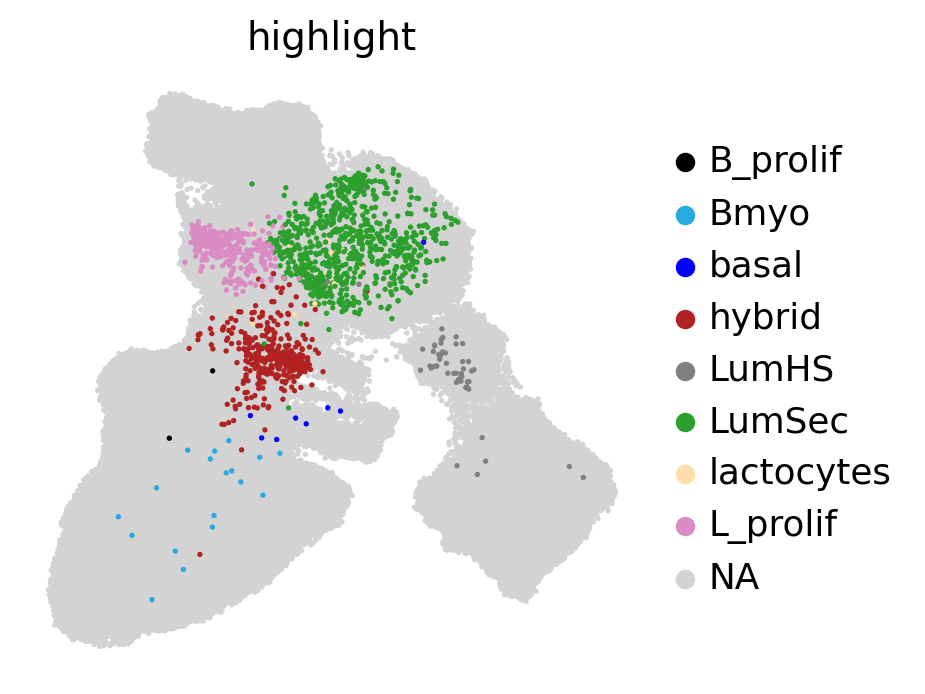

In [16]:
met = sub[sub.obs['orig.ident'].isin(["tum_ortho_colIV"])]
full.obs['highlight'] = met.obs['integrated_cell']

#pl.rcParams["figure.figsize"] = (5,5)
sc.pl.umap(
    full,
    color=["highlight"],
    frameon=False,
    ncols=1,
    size=15,
    palette=['black', '#27AAE1','blue','firebrick','grey','#2ca02c','navajowhite','#da8bc3',
                         ],
)

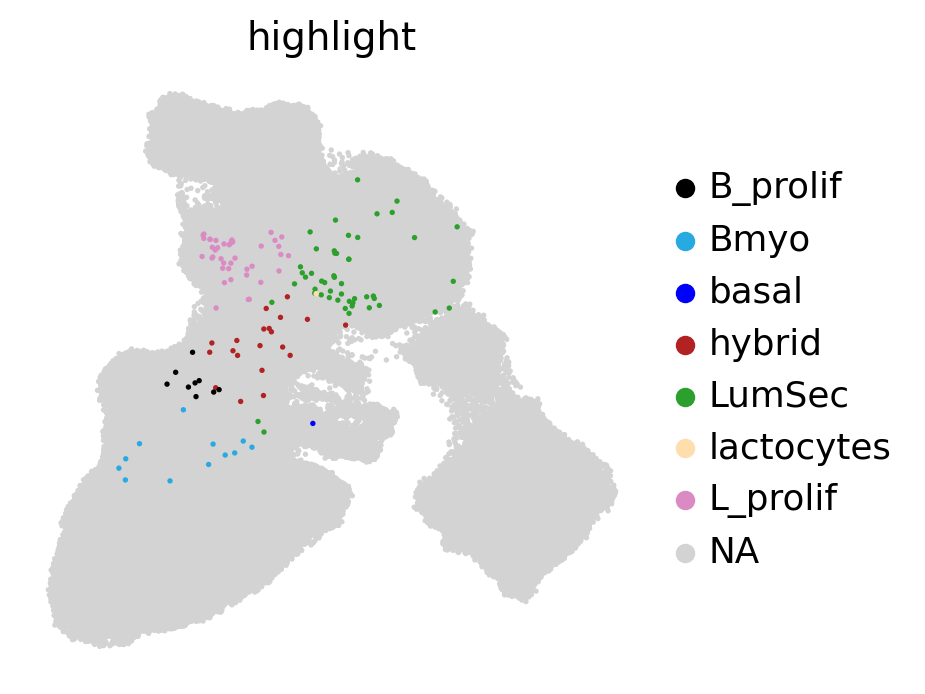

In [8]:
met = sub[sub.obs['orig.ident'].isin(["lung_1"])]
full.obs['highlight'] = met.obs['integrated_cell']

#pl.rcParams["figure.figsize"] = (5,5)
sc.pl.umap(
    full,
    color=["highlight"],
    frameon=False,
    ncols=1,
    size=15,
    palette=['black', '#27AAE1','blue','firebrick','#2ca02c','navajowhite','#da8bc3',
                         ],
)

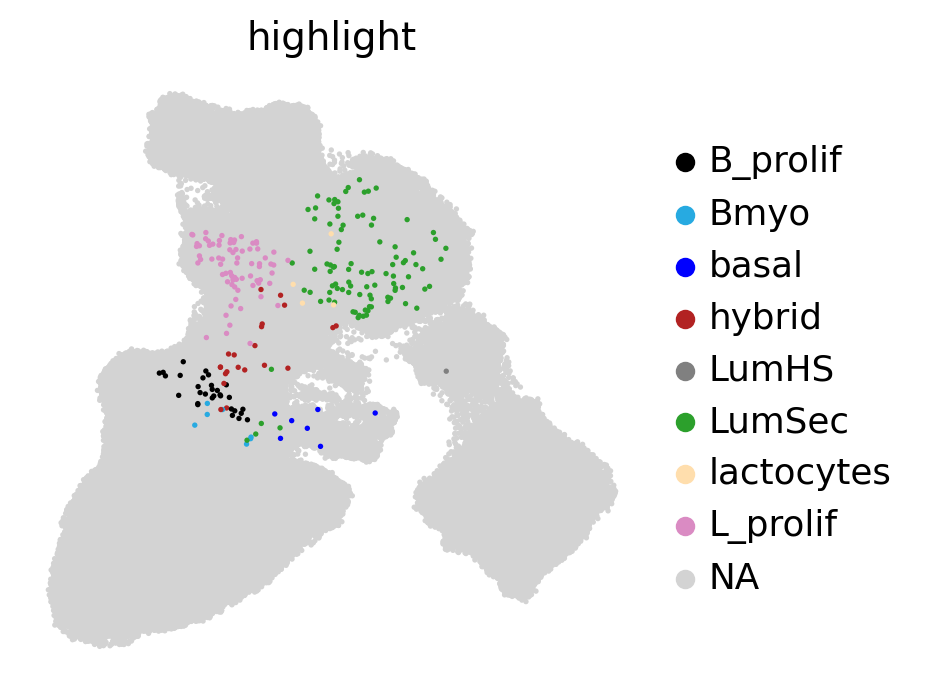

In [19]:
met = sub[sub.obs['orig.ident'].isin(["lung_2"])]
full.obs['highlight'] = met.obs['integrated_cell']

#pl.rcParams["figure.figsize"] = (5,5)
sc.pl.umap(
    full,
    color=["highlight"],
    frameon=False,
    ncols=1,
    size=15,
    palette=['black', '#27AAE1','blue','firebrick','grey','#2ca02c','navajowhite','#da8bc3',
                         ],
)

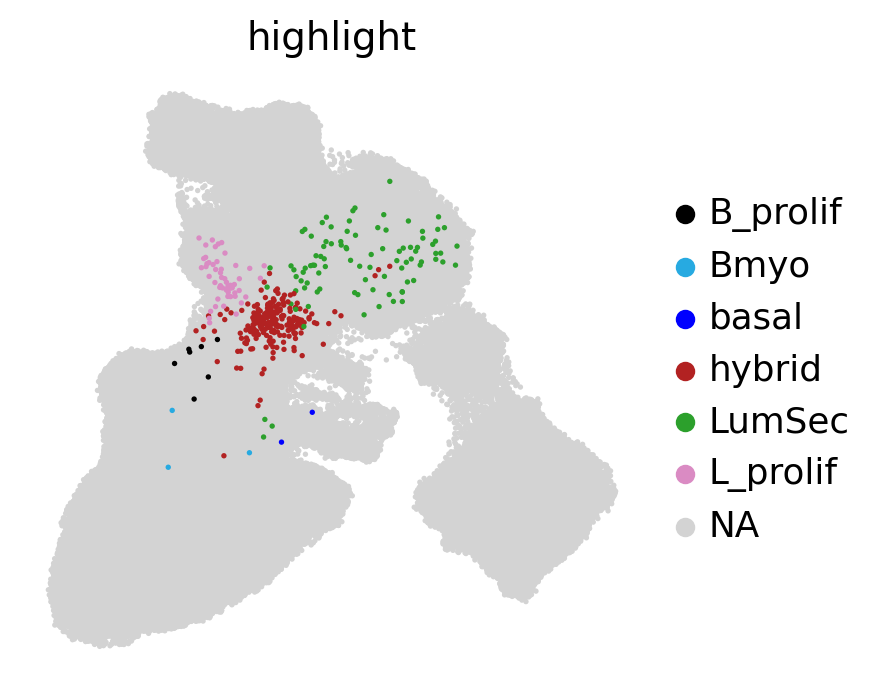

In [22]:
met = sub[sub.obs['orig.ident'].isin(["lung_3"])]
full.obs['highlight'] = met.obs['integrated_cell']

#pl.rcParams["figure.figsize"] = (5,5)
sc.pl.umap(
    full,
    color=["highlight"],
    frameon=False,
    ncols=1,
    size=15,
    palette=['black', '#27AAE1','blue','firebrick','#2ca02c','#da8bc3',
                         ],
)

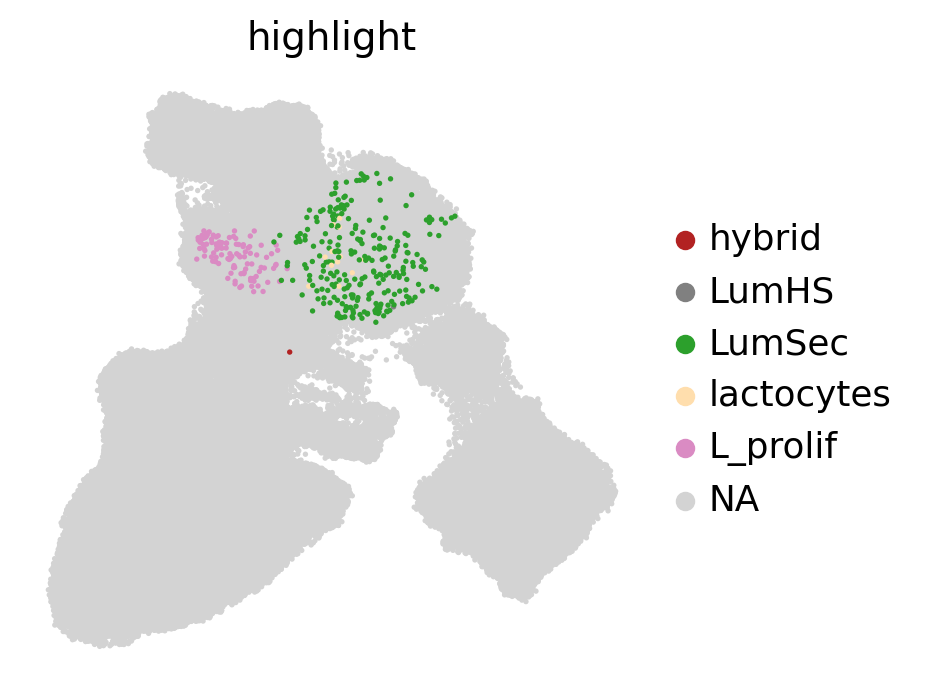

In [24]:
met = sub[sub.obs['orig.ident'].isin(["lung_4"])]
full.obs['highlight'] = met.obs['integrated_cell']

#pl.rcParams["figure.figsize"] = (5,5)
sc.pl.umap(
    full,
    color=["highlight"],
    frameon=False,
    ncols=1,
    size=15,
    palette=['firebrick','grey','#2ca02c','navajowhite','#da8bc3',
                         ],
)

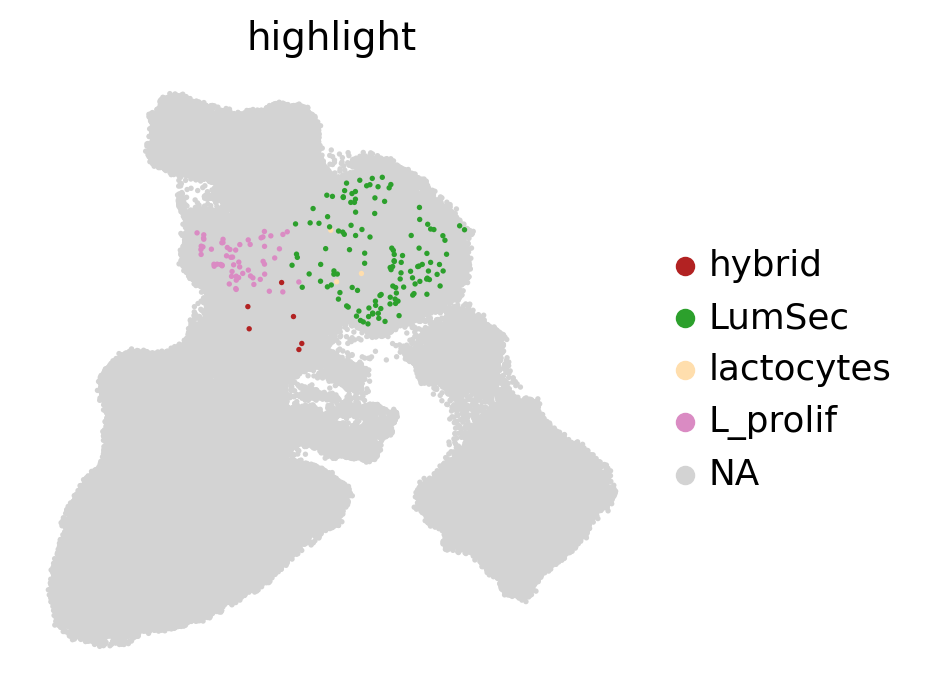

In [27]:
met = sub[sub.obs['orig.ident'].isin(["liver_1"])]
full.obs['highlight'] = met.obs['integrated_cell']

#pl.rcParams["figure.figsize"] = (5,5)
sc.pl.umap(
    full,
    color=["highlight"],
    frameon=False,
    ncols=1,
    size=15,
    palette=['firebrick','#2ca02c','navajowhite','#da8bc3',
                         ],
)

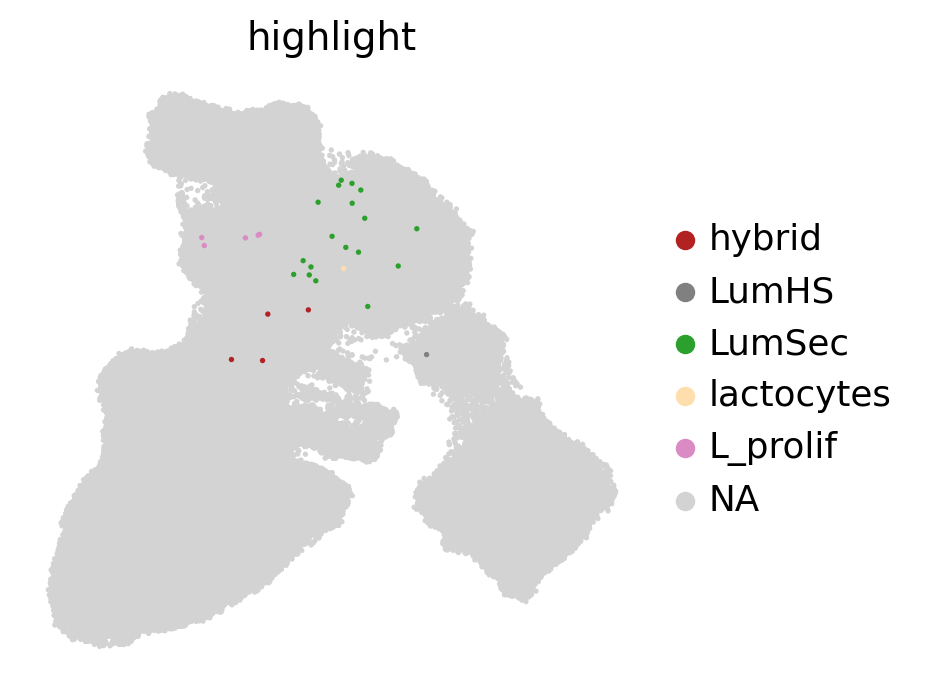

In [29]:
met = sub[sub.obs['orig.ident'].isin(["liver_2"])]
full.obs['highlight'] = met.obs['integrated_cell']

#pl.rcParams["figure.figsize"] = (5,5)
sc.pl.umap(
    full,
    color=["highlight"],
    frameon=False,
    ncols=1,
    size=15,
    palette=['firebrick','grey','#2ca02c','navajowhite','#da8bc3',
                         ],
)

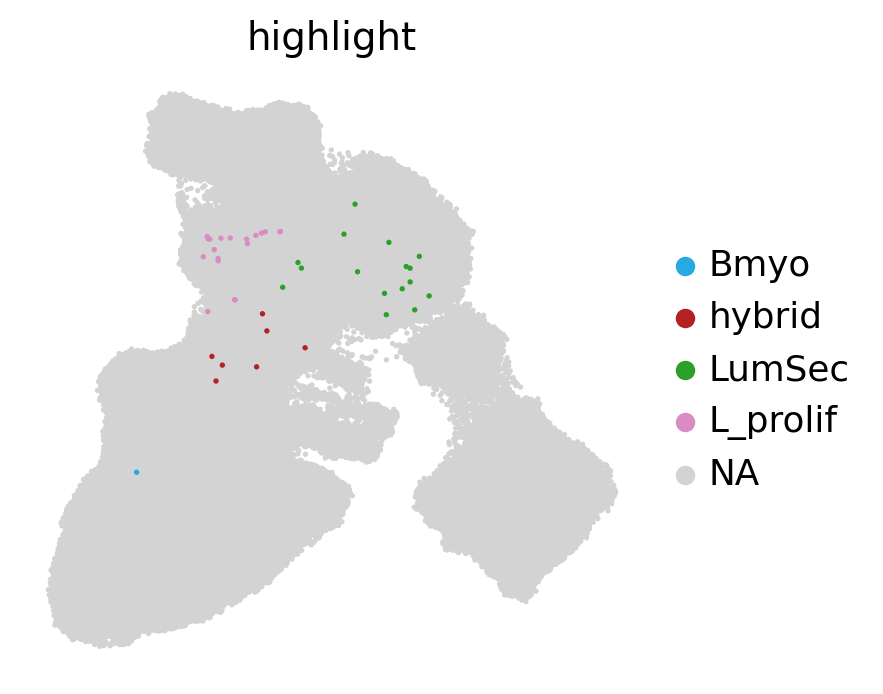

In [32]:
met = sub[sub.obs['orig.ident'].isin(["liver_3"])]
full.obs['highlight'] = met.obs['integrated_cell']

#pl.rcParams["figure.figsize"] = (5,5)
sc.pl.umap(
    full,
    color=["highlight"],
    frameon=False,
    ncols=1,
    size=15,
    palette=['#27AAE1','firebrick','#2ca02c','#da8bc3',
                         ],
)

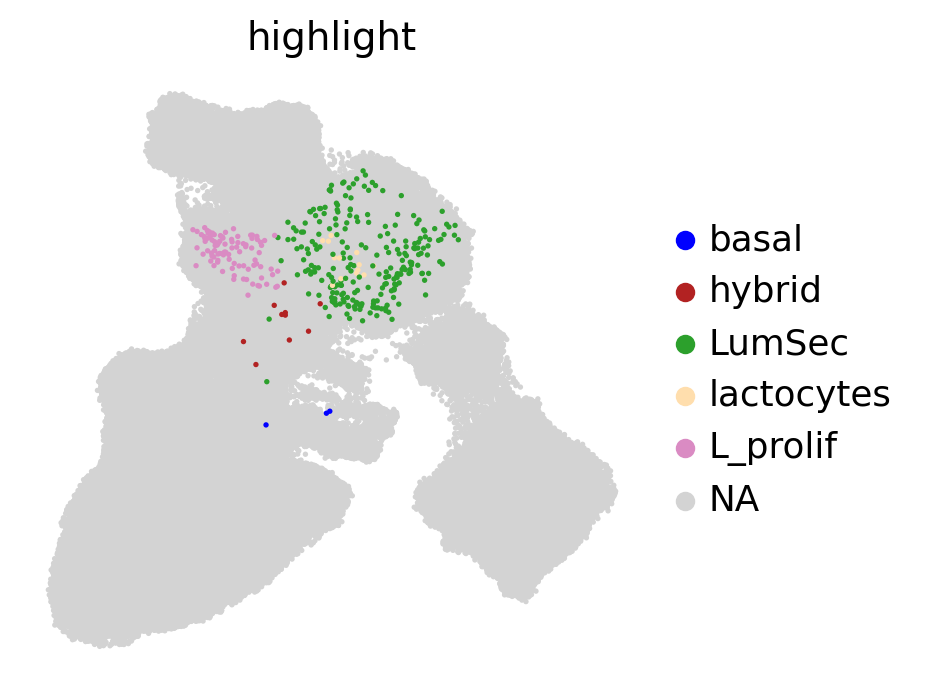

In [42]:
met = sub[sub.obs['orig.ident'].isin(["liver_4"])]
full.obs['highlight'] = met.obs['integrated_cell']

#pl.rcParams["figure.figsize"] = (5,5)
sc.pl.umap(
    full,
    color=["highlight"],
    frameon=False,
    ncols=1,
    size=15,
    palette=['blue','firebrick','#2ca02c','navajowhite','#da8bc3',
                         ],
)

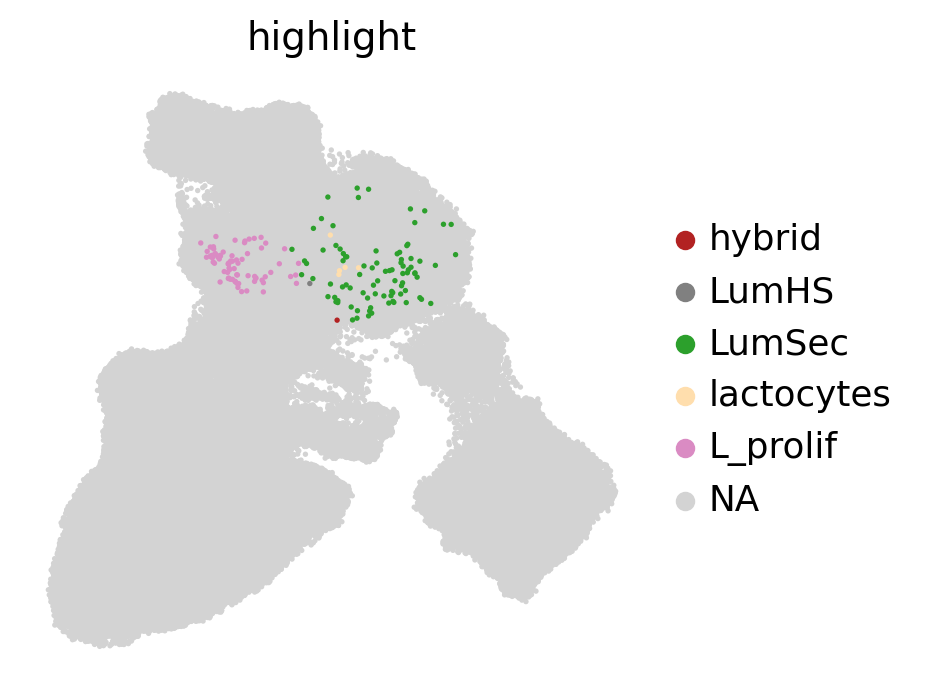

In [34]:
met = sub[sub.obs['orig.ident'].isin(["brain_1"])]
full.obs['highlight'] = met.obs['integrated_cell']

#pl.rcParams["figure.figsize"] = (5,5)
sc.pl.umap(
    full,
    color=["highlight"],
    frameon=False,
    ncols=1,
    size=15,
    palette=['firebrick','grey','#2ca02c','navajowhite','#da8bc3',
                         ],
)

In [23]:
sub.obs['Fig_7_ident'] = (
    sub.obs["orig.ident"]
    .map(lambda x: {"tum_111121": "primary",
                    "tum_111121_enr": "primary",
                    "tum_ortho_colIV": "orthotopic_1",
                    "tum_ortho_colD": "orthotopic_2",
                    "lung_1": "lung_0.5",
                    "lung_2": "lung_0.4",
                    "lung_3": "lung_2.6",
                    "lung_4": "lung_12.0",
                    "liver_1": "liver_1.7",
                    "liver_2": "liver_0.8",
                    "liver_3": "liver_1.2",
                    "liver_4": "liver_12.4",
                    "brain_1": "brain_8.2"}.get(x, x))
    .astype("category")
)

/tmp/ipykernel_4012799/2963947272.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  sub.obs['Fig_7_ident'] = (


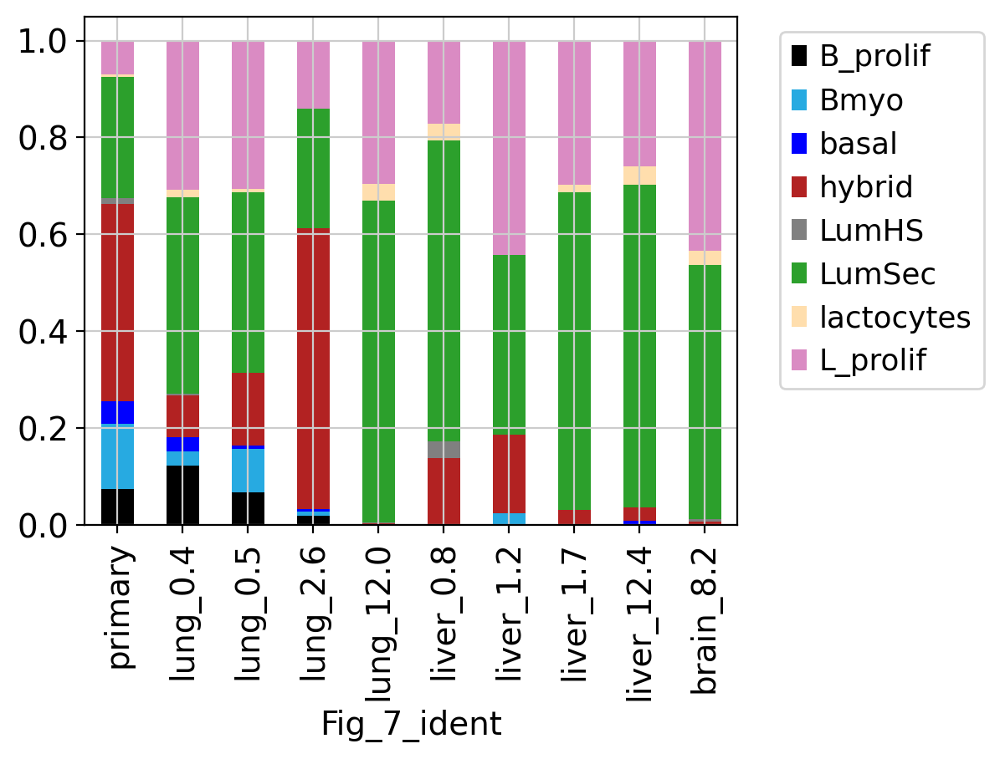

In [11]:
pl.rcParams["figure.figsize"] = (5,4)
tmp = pd.crosstab(sub.obs['integrated_cell'],sub.obs['Fig_7_ident'], 
                  normalize='columns').reindex()[["primary",
                                                  #"orthotopic_1",
                                                  #"orthotopic_2",
                                                  "lung_0.4",
                                                  "lung_0.5",
                                                  "lung_2.6",
                                                  "lung_12.0",
                                                  "liver_0.8",
                                                  "liver_1.2",
                                                  "liver_1.7",
                                                  "liver_12.4",
                                                  "brain_8.2"]].T.plot(kind='bar', 
                                                                                            stacked=True,
                                                                                            color=['black', 
                                                                                                                        '#27AAE1',
                                                                                                                        'blue',
                                                                                                                        'firebrick',
                                                                                                                        'grey',
                                                                                                                        '#2ca02c',
                                                                                                                        'navajowhite',
                                                                                                                       '#da8bc3'])
tmp.legend(title='', bbox_to_anchor=(1.4, 1.0),loc='upper right')

pl.savefig('Fig_7_mets_integrated_cell_stackedbar_plot.pdf', bbox_inches='tight')

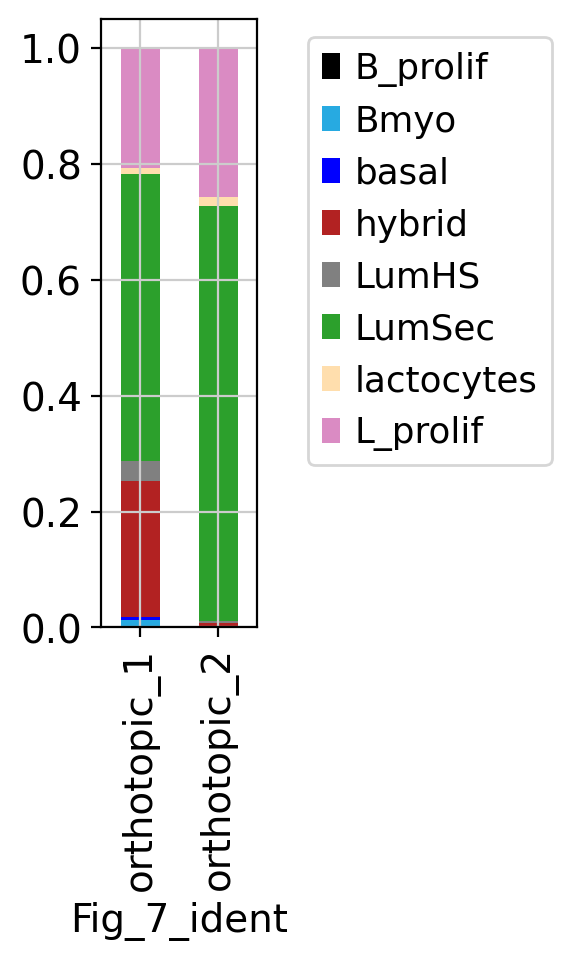

In [16]:
pl.rcParams["figure.figsize"] = (1,4)
tmp = pd.crosstab(sub.obs['integrated_cell'],sub.obs['Fig_7_ident'], 
                  normalize='columns').reindex()[["orthotopic_1",
                                                  "orthotopic_2"]].T.plot(kind='bar', 
                                                                                            stacked=True,
                                                                                            color=['black', 
                                                                                                                        '#27AAE1',
                                                                                                                        'blue',
                                                                                                                        'firebrick',
                                                                                                                        'grey',
                                                                                                                        '#2ca02c',
                                                                                                                        'navajowhite',
                                                                                                                       '#da8bc3'])
tmp.legend(title='', bbox_to_anchor=(3, 1.0),loc='upper right')

pl.savefig('Fig_7_mets_integrated_cell_stackedbar_plot.pdf', bbox_inches='tight')

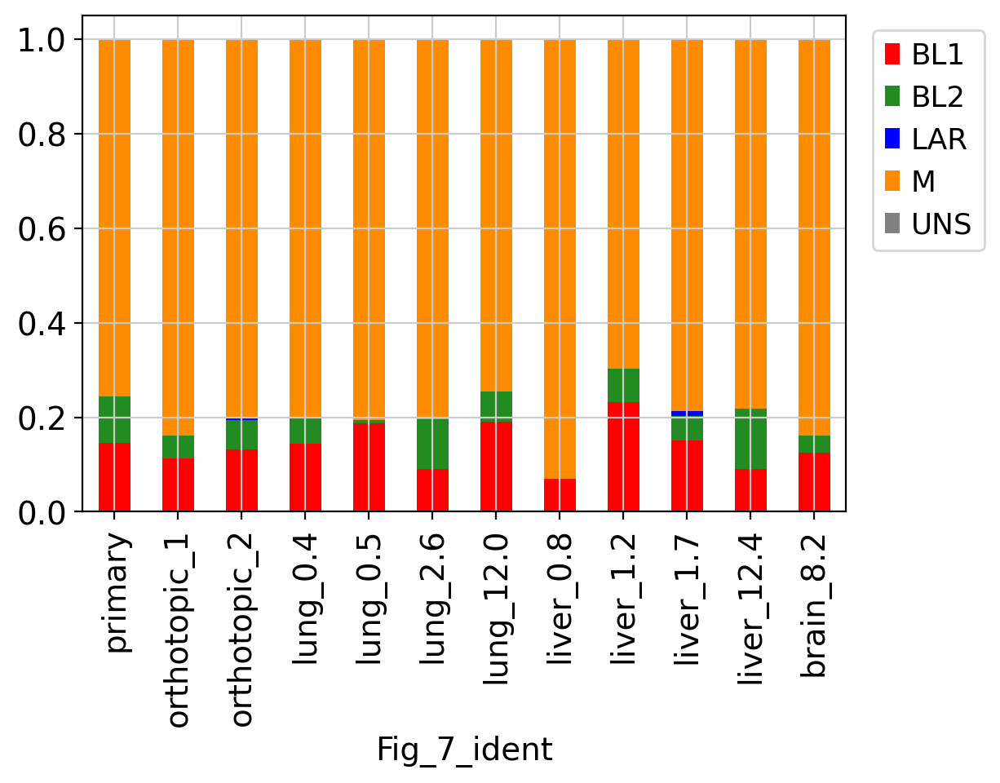

In [55]:
pl.rcParams["figure.figsize"] = (6,4)
tmp = pd.crosstab(sub.obs['subtype'],sub.obs['Fig_7_ident'], 
                  normalize='columns').reindex()[["primary",
                                                  "orthotopic_1",
                                                  "orthotopic_2",
                                                  "lung_0.4",
                                                  "lung_0.5",
                                                  "lung_2.6",
                                                  "lung_12.0",
                                                  "liver_0.8",
                                                  "liver_1.2",
                                                  "liver_1.7",
                                                  "liver_12.4",
                                                  "brain_8.2"]].T.plot(kind='bar',
                                                                       stacked=True,
                                                                       color=['red','forestgreen','blue','darkorange','grey'])
tmp.legend(title='', bbox_to_anchor=(1.2, 1.0),loc='upper right')

pl.savefig('Fig_7_mets_subtype_proportions_stackedbar_plot.pdf', bbox_inches='tight')

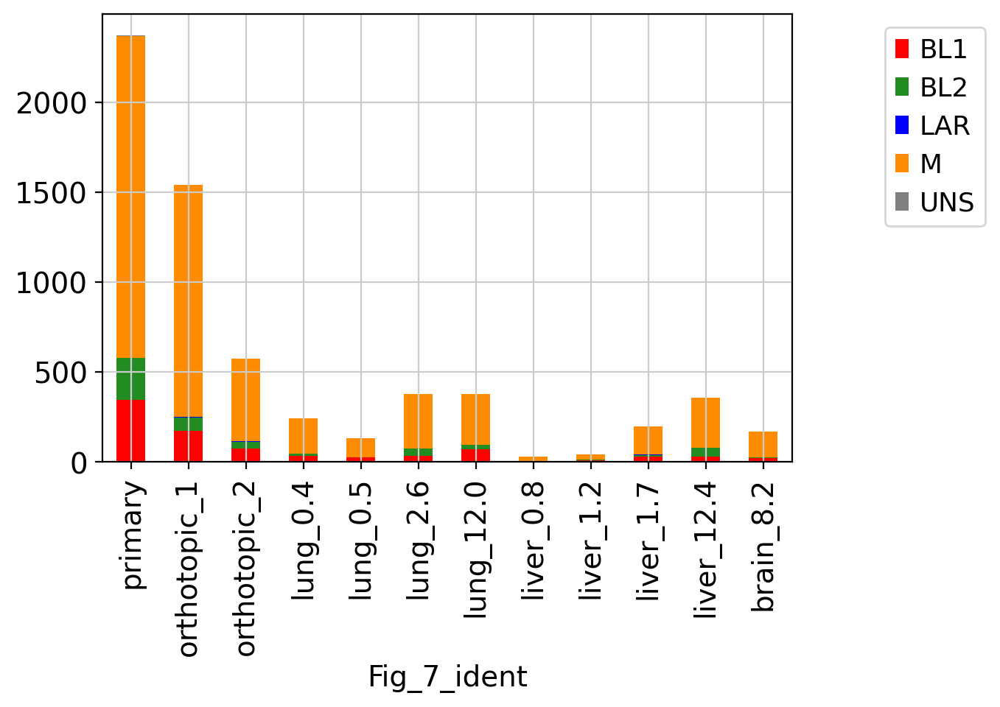

In [58]:
pl.rcParams["figure.figsize"] = (6,4)
tmp = pd.crosstab(sub.obs['subtype'],sub.obs['Fig_7_ident']).reindex()[["primary",
                                                  "orthotopic_1",
                                                  "orthotopic_2",
                                                  "lung_0.4",
                                                  "lung_0.5",
                                                  "lung_2.6",
                                                  "lung_12.0",
                                                  "liver_0.8",
                                                  "liver_1.2",
                                                  "liver_1.7",
                                                  "liver_12.4",
                                                  "brain_8.2"]].T.plot(kind='bar',
                                                                       stacked=True,
                                                                       color=['red','forestgreen','blue','darkorange','grey'])
tmp.legend(title='', bbox_to_anchor=(1.3, 1.0),loc='upper right')

pl.savefig('Fig_7_mets_subtype_stackedbar_plot.pdf', bbox_inches='tight')

In [79]:
met = full[full.obs['orig.ident'].isin(["brain_1",
                                     "lung_1","lung_2","lung_3","lung_4",
                                     "liver_1","liver_2","liver_3","liver_4"])]

/opt/apps/python/3.10.2/lib/python3.10/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/opt/apps/python/3.10.2/lib/python3.10/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


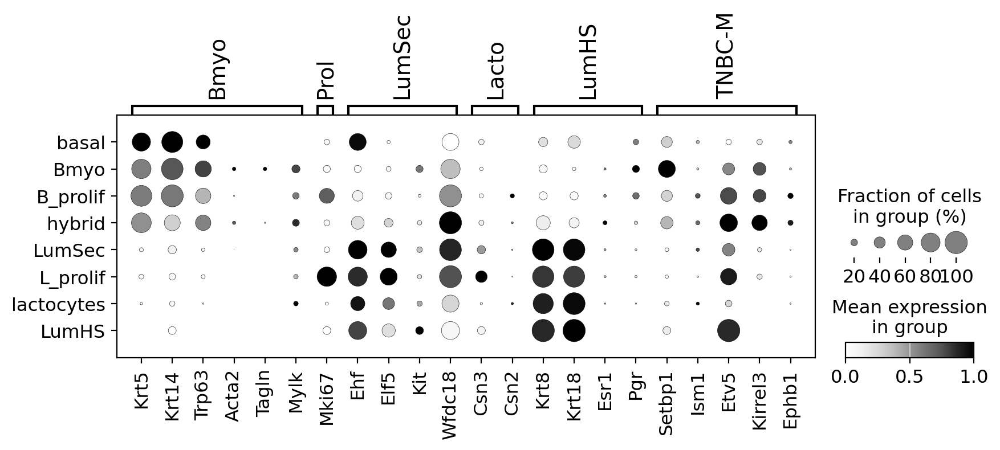

In [80]:
marker_genes = {
    "Bmyo": ["Krt5","Krt14","Trp63","Acta2","Tagln","Mylk"],
    "Prol": ["Mki67"],
    "LumSec": ["Ehf","Elf5","Kit","Wfdc18"],
    "Lacto": ["Csn3","Csn2"],
    "LumHS": ["Krt8","Krt18","Esr1","Pgr"],
    "TNBC-M":["Setbp1","Ism1","Etv5","Kirrel3","Ephb1"]}


sc.pl.dotplot(met, marker_genes, groupby="integrated_cell",
              standard_scale="var",
              categories_order=['basal','Bmyo','B_prolif',
              'hybrid','LumSec','L_prolif','lactocytes','LumHS'],
              swap_axes=False,cmap='Greys',save='_met_canonical_M.pdf')

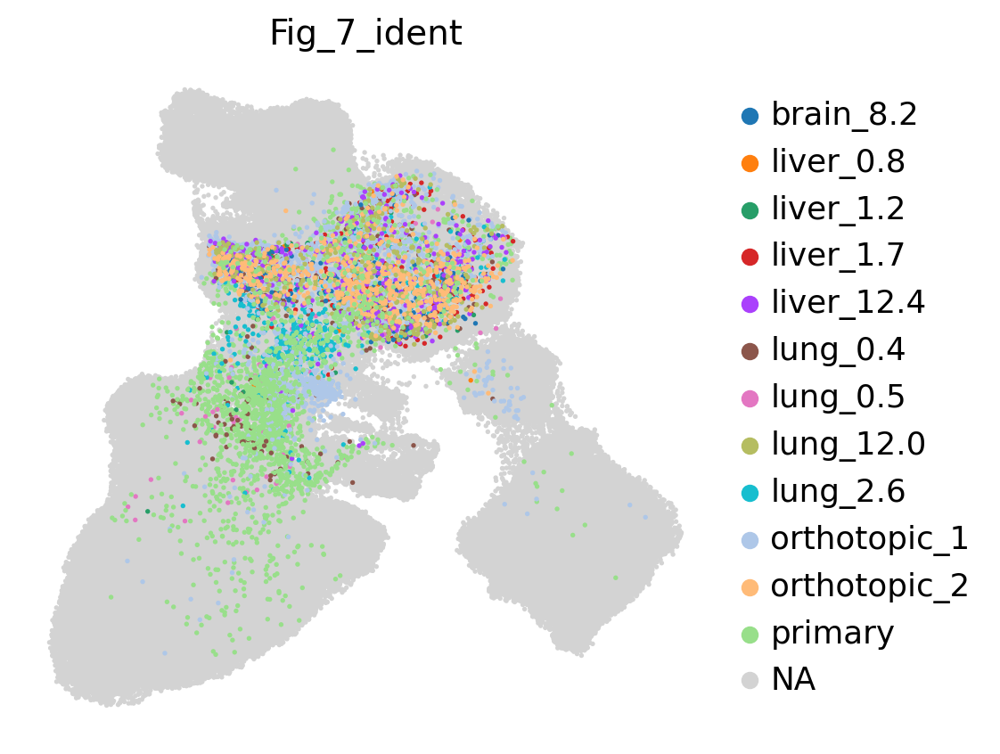

In [20]:
full.obs['Fig_7_ident'] = sub.obs['Fig_7_ident']

pl.rcParams["figure.figsize"] = (5,5)
sc.pl.umap(
    full,
    color=["Fig_7_ident"],
    frameon=False,
    ncols=1,
    size=15,
)

In [25]:
e18 = full[full.obs['orig.ident'].isin(["pMFP_1","pMFP_2","pMFP_3","pMFP_4","pMFP_5","pMFP_6","pMFP_7","pMFP_8","pMFP_9","pMFP_10",
                                           "pMFP_11","pMFP_12","pMFP_13","pMFP_14","pMFP_15",
                                       ])]
e18 = e18[~e18.obs['cnv_us'].isin(["not.defined"])]

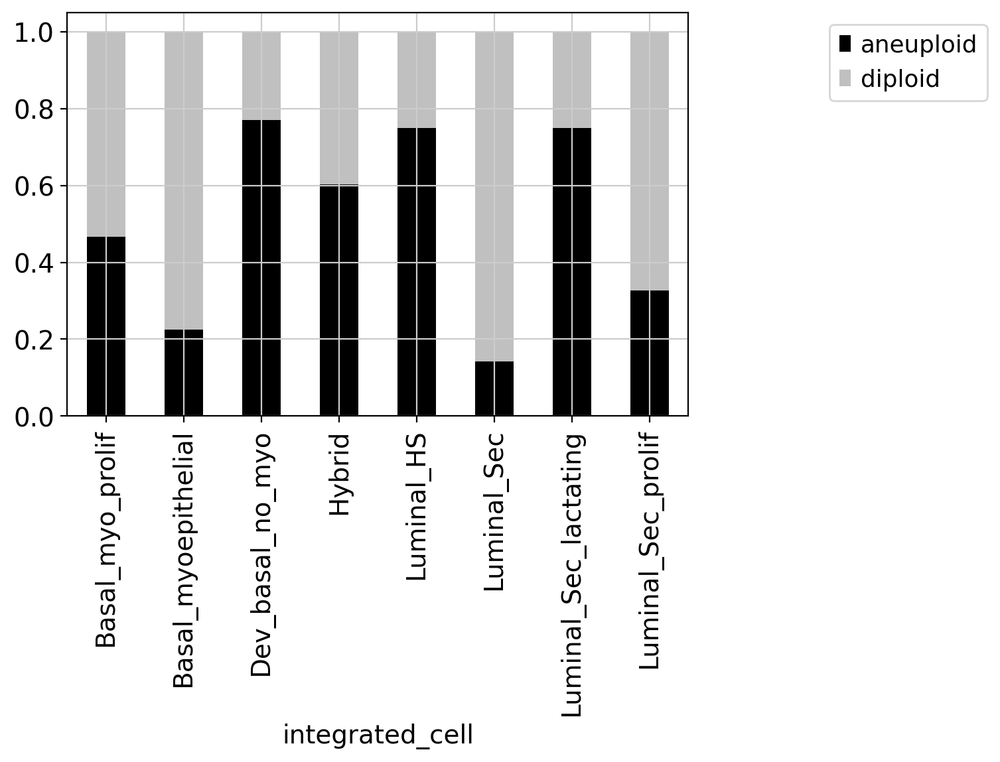

In [29]:
pl.rcParams["figure.figsize"] = (6,4)
tmp = pd.crosstab(e18.obs['cnv_us'],e18.obs['integrated_cell'], 
                  normalize='columns').T.plot(kind='bar',stacked=True,color=['black','silver'])
tmp.legend(title='', bbox_to_anchor=(1.5, 1.0),loc='upper right')

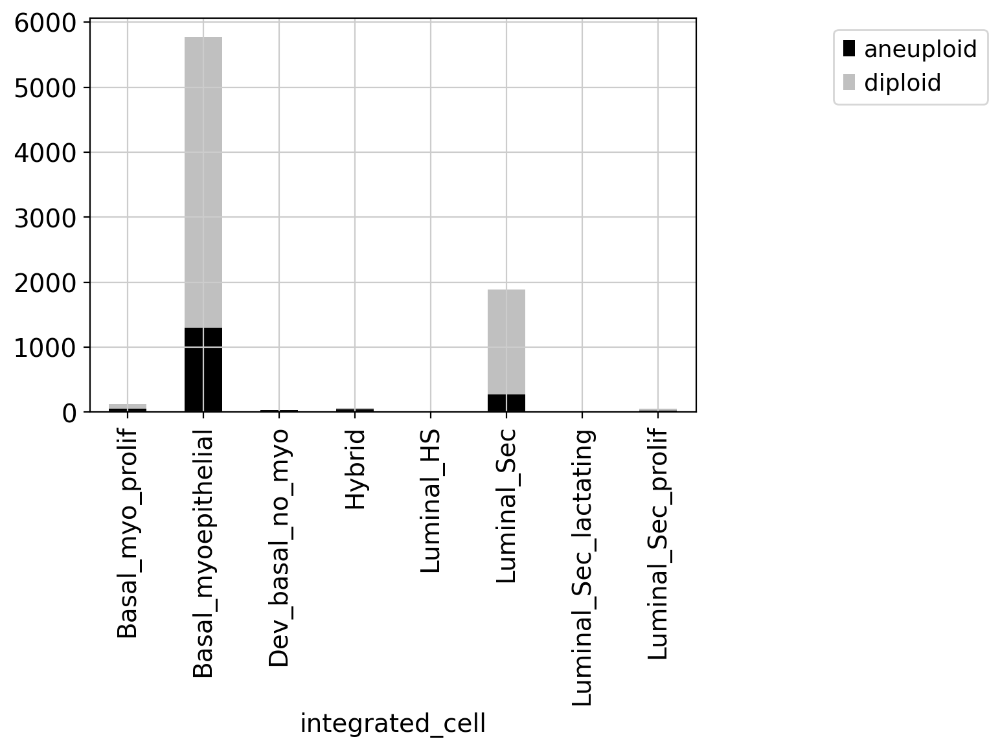

In [30]:
pl.rcParams["figure.figsize"] = (6,4)
tmp = pd.crosstab(e18.obs['cnv_us'],e18.obs['integrated_cell']).T.plot(kind='bar',stacked=True,color=['black','silver'])
tmp.legend(title='', bbox_to_anchor=(1.5, 1.0),loc='upper right')

In [32]:
pd.crosstab(e18.obs['dataset'],e18.obs['integrated_cell'])

integrated_cell,Basal_myo_prolif,Basal_myoepithelial,Dev_basal_no_myo,Hybrid,Luminal_HS,Luminal_Sec,Luminal_Sec_lactating,Luminal_Sec_prolif
dataset,,,,,,,,
wap_cre,118,5771,35,64,2452,1888,4,55


## IMPORTANT: Updated metastases burdens

In [4]:
full.obs['Updated_Fig_7_ident'] = (
    full.obs["orig.ident"]
    .map(lambda x: {"tum_111121": "primary",
                    "tum_111121_enr": "primary",
                    "tum_ortho_colIV": "orthotopic_1",
                    "tum_ortho_colD": "orthotopic_2",
                    "lung_1": "lung_1.1",
                    "lung_2": "lung_0.9",
                    "lung_3": "lung_4.5",
                    "lung_4": "lung_25.9",
                    "liver_1": "liver_3.4",
                    "liver_2": "liver_1.4",
                    "liver_3": "liver_1.5",
                    "liver_4": "liver_13.6",
                    "brain_1": "brain_12.5"}.get(x, x))
    .astype("category")
)

In [5]:
full

AnnData object with n_obs × n_vars = 177306 × 838
    obs: 'orig.ident', 'pct_counts_mt', 'pct_counts_ribo', 'cell_type', 'barcode', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'leiden', 'highlight', 'dataset', 'dev_stage', '_scvi_batch', '_scvi_labels', 'scanvi_labels', 'batch', 'predictions_scanvi', 'cell_type_blg', 'cell_type_wap', 'cell_type_mets', 'cell_type_vis', 'integrated_cell', 'Updated_Fig_7_ident'
    uns: '_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'leiden', 'umap', 'dataset_colors', 'cell_type_blg_colors', 'cell_type_wap_colors', 'cell_type_mets_colors', 'cell_type_vis_colors', 'predictions_scanvi_colors', 'leiden_colors', 'rank_genes_groups', 'dendrogram_leiden', 'integrated_cell_colors'
    obsm: 'X_pca', 'X_umap